<a href="https://colab.research.google.com/github/atharvam505-blip/userforecast/blob/main/Predictive_Analytics_FoBA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import required library
import pandas as pd



Mounted at /content/drive


In [ ]:
# Update the path to where your CSV is stored in Google Drive
file_path = "/content/drive/MyDrive/Campus_Courses/Foundation of Business Analytics/loan_data.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Preview the data
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


Prompt# 1: Write a robust python code to load the dataset, inspect variable types, handle missing values, encode categorical variables, and define the binary target variable and predictor set.


# Task
Inspect the data types of each column and identify any missing values in the `df` DataFrame, then handle any missing values found. Next, encode any remaining categorical variables in `df`, and finally, define the target variable as 'loan_status' and the predictor variables as all other columns, making sure they are appropriately preprocessed for model training.

## Inspect Data Types and Missing Values

### Subtask:
Inspect the data types of each column and identify any missing values in the dataset.


**Reasoning**:
The subtask requires inspecting data types and missing values. The `.info()` method will display data types and non-null counts, and `isnull().sum()` will calculate missing values for each column.



In [ ]:
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_de

## Handle Missing Values

### Subtask:
Implement a strategy to handle missing values, such as imputation or dropping rows/columns, based on the inspection results.


### No Missing Values Found

Based on the inspection using `df.info()` and `df.isnull().sum()`, there are no missing values in the `df` DataFrame. Therefore, no imputation or dropping of rows/columns is necessary at this stage.

## Encode Categorical Variables

### Subtask:
Identify categorical columns and apply appropriate encoding techniques.


**Reasoning**:
First, I'll encode the binary categorical columns 'person_gender' and 'previous_loan_defaults_on_file' by mapping their string values to numerical representations (0 and 1) as specified in the instructions. This directly converts these columns into a format suitable for machine learning models.



In [ ]:
df['person_gender'] = df['person_gender'].map({'female': 0, 'male': 1})
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'No': 0, 'Yes': 1})

print("Encoded 'person_gender' and 'previous_loan_defaults_on_file' columns.")
print(df[['person_gender', 'previous_loan_defaults_on_file']].head())

Encoded 'person_gender' and 'previous_loan_defaults_on_file' columns.
   person_gender  previous_loan_defaults_on_file
0              0                               0
1              0                               1
2              0                               0
3              0                               0
4              1                               0


**Reasoning**:
Now that the binary categorical columns have been encoded, the next step is to apply one-hot encoding to the remaining categorical columns ('person_education', 'person_home_ownership', 'loan_intent') to convert them into a numerical format suitable for machine learning models. I will use `pd.get_dummies` and concatenate the new columns with the existing DataFrame, dropping the original categorical columns and setting `drop_first=True` to avoid multicollinearity.



In [ ]:
categorical_cols_to_encode = ['person_education', 'person_home_ownership', 'loan_intent']
df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

print("DataFrame after one-hot encoding:")
print(df.head())

DataFrame after one-hot encoding:
   person_age  person_gender  person_income  person_emp_exp  loan_amnt  \
0        22.0              0        71948.0               0    35000.0   
1        21.0              0        12282.0               0     1000.0   
2        25.0              0        12438.0               3     5500.0   
3        23.0              0        79753.0               0    35000.0   
4        24.0              1        66135.0               1    35000.0   

   loan_int_rate  loan_percent_income  cb_person_cred_hist_length  \
0          16.02                 0.49                         3.0   
1          11.14                 0.08                         2.0   
2          12.87                 0.44                         3.0   
3          15.23                 0.44                         2.0   
4          14.27                 0.53                         4.0   

   credit_score  previous_loan_defaults_on_file  ...  \
0           561                               0  .

## Define Target and Predictor Variables

### Subtask:
Define the target variable `y` as 'loan_status' and the predictor variables `X` as all other columns in the DataFrame.

**Reasoning**:
Now that all categorical variables have been encoded, the next step is to separate the dataset into features (X) and the target variable (y). The 'loan_status' column will be assigned to 'y', and all other columns will be assigned to 'X'.



In [ ]:
y = df['loan_status']
X = df.drop('loan_status', axis=1)

print("Shape of X (predictor variables):", X.shape)
print("Shape of y (target variable):", y.shape)

Shape of X (predictor variables): (45000, 22)
Shape of y (target variable): (45000,)


## Summary:

### Data Analysis Key Findings

*   The initial `df` DataFrame consists of 45,000 entries and 14 columns, comprising 6 `float64` columns, 3 `int64` columns, and 5 `object` (categorical) columns.
*   No missing values were found in any column of the `df` DataFrame.
*   Two categorical columns were binary encoded:
    *   `person_gender` was mapped to 0 for 'female' and 1 for 'male'.
    *   `previous_loan_defaults_on_file` was mapped to 0 for 'No' and 1 for 'Yes'.
*   Three remaining categorical columns (`person_education`, `person_home_ownership`, and `loan_intent`) were one-hot encoded using `drop_first=True`, which expanded the DataFrame's column count.
*   The target variable `y` was defined as `loan_status` with a shape of (45000,).
*   The predictor variables `X` were defined as all other columns, resulting in a shape of (45000, 22).

### Insights or Next Steps

*   The absence of missing values significantly streamlines the data preprocessing phase, allowing for direct focus on feature engineering and model building.
*   The dataset is now fully prepared for machine learning model training, with all categorical features appropriately encoded and the target and predictor variables clearly defined.


Prompt # 2: Write a robust python code to examine the class distribution of the binary outcome variable and visualize class imbalance.

Class distribution of 'loan_status':
loan_status
0    35000
1    10000
Name: count, dtype: int64

Percentage of each class:
loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64


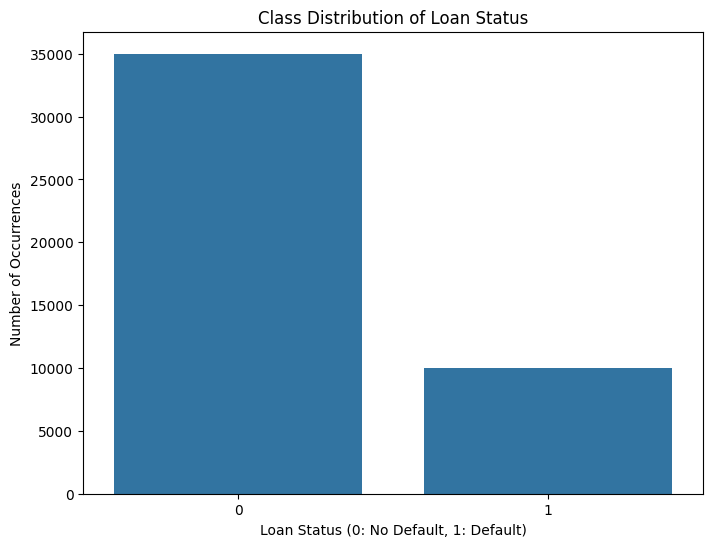

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Examine class distribution of the binary outcome variable (y)
print("Class distribution of 'loan_status':")
class_distribution = y.value_counts()
print(class_distribution)
print("\nPercentage of each class:")
print(y.value_counts(normalize=True) * 100)

# Visualize class imbalance
plt.figure(figsize=(8, 6))
sns.countplot(x=y)
plt.title('Class Distribution of Loan Status')
plt.xlabel('Loan Status (0: No Default, 1: Default)')
plt.ylabel('Number of Occurrences')
plt.show()

Write a robust python code to split the data into training and testing sets using stratified sampling.


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True) * 100)

Shape of X_train: (36000, 22)
Shape of X_test: (9000, 22)
Shape of y_train: (36000,)
Shape of y_test: (9000,)

Class distribution in y_train:
loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64

Class distribution in y_test:
loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64


Write a robust Python code to standardize and scale numerical features while preventing data leakage.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical and categorical columns
# Binary encoded columns and one-hot encoded columns should not be scaled.
# Assuming boolean columns generated by get_dummies are already effectively binary categorical.
numerical_cols = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'credit_score'
]

categorical_cols = [col for col in X_train.columns if col not in numerical_cols]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on X_train numerical columns and transform both X_train and X_test numerical columns
X_train_scaled_numerical = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled_numerical = scaler.transform(X_test[numerical_cols])

# Convert scaled numerical arrays back to DataFrames with column names
X_train_scaled_numerical_df = pd.DataFrame(X_train_scaled_numerical, columns=numerical_cols, index=X_train.index)
X_test_scaled_numerical_df = pd.DataFrame(X_test_scaled_numerical, columns=numerical_cols, index=X_test.index)

# Concatenate scaled numerical features with original categorical features for X_train
X_train_scaled = pd.concat([
    X_train_scaled_numerical_df,
    X_train[categorical_cols]
], axis=1)

# Concatenate scaled numerical features with original categorical features for X_test
X_test_scaled = pd.concat([
    X_test_scaled_numerical_df,
    X_test[categorical_cols]
], axis=1)

print("X_train_scaled head:")
print(X_train_scaled.head())
print("\nX_test_scaled head:")
print(X_test_scaled.head())

X_train_scaled head:
       person_age  person_income  person_emp_exp  loan_amnt  loan_int_rate  \
6048    -0.622502      -0.256600       -0.561597  -0.823150      -1.687749   
3346    -0.787921      -0.411269       -0.561597   0.224243      -0.001061   
17998    0.204591       1.902342        0.262920   0.065547       0.563408   
24988    0.370009       0.186994        0.757630  -0.569236       0.832203   
23231    0.204591      -0.089147        0.262920  -0.251845      -0.169058   

       loan_percent_income  cb_person_cred_hist_length  credit_score  \
6048             -0.800883                   -0.480436      0.464300   
3346              1.154322                   -0.996078      0.026852   
17998            -1.145920                    0.808671      0.106388   
24988            -0.915896                    0.550850      0.981285   
23231            -0.340835                    0.550850      0.225692   

       person_gender  previous_loan_defaults_on_file  ...  \
6048            

Write a robust python code to compute and analyze the correlation structure among numerical predictors.


Correlation Matrix of Numerical Predictors:
                            person_age  person_income  person_emp_exp  \
person_age                    1.000000       0.204774        0.954426   
person_income                 0.204774       1.000000        0.196661   
person_emp_exp                0.954426       0.196661        1.000000   
loan_amnt                     0.050283       0.231729        0.042884   
loan_int_rate                 0.013328       0.001738        0.016060   
loan_percent_income          -0.046246      -0.226850       -0.043352   
cb_person_cred_hist_length    0.864417       0.124504        0.826360   
credit_score                  0.176849       0.035708        0.185017   

                            loan_amnt  loan_int_rate  loan_percent_income  \
person_age                   0.050283       0.013328            -0.046246   
person_income                0.231729       0.001738            -0.226850   
person_emp_exp               0.042884       0.016060            -0.

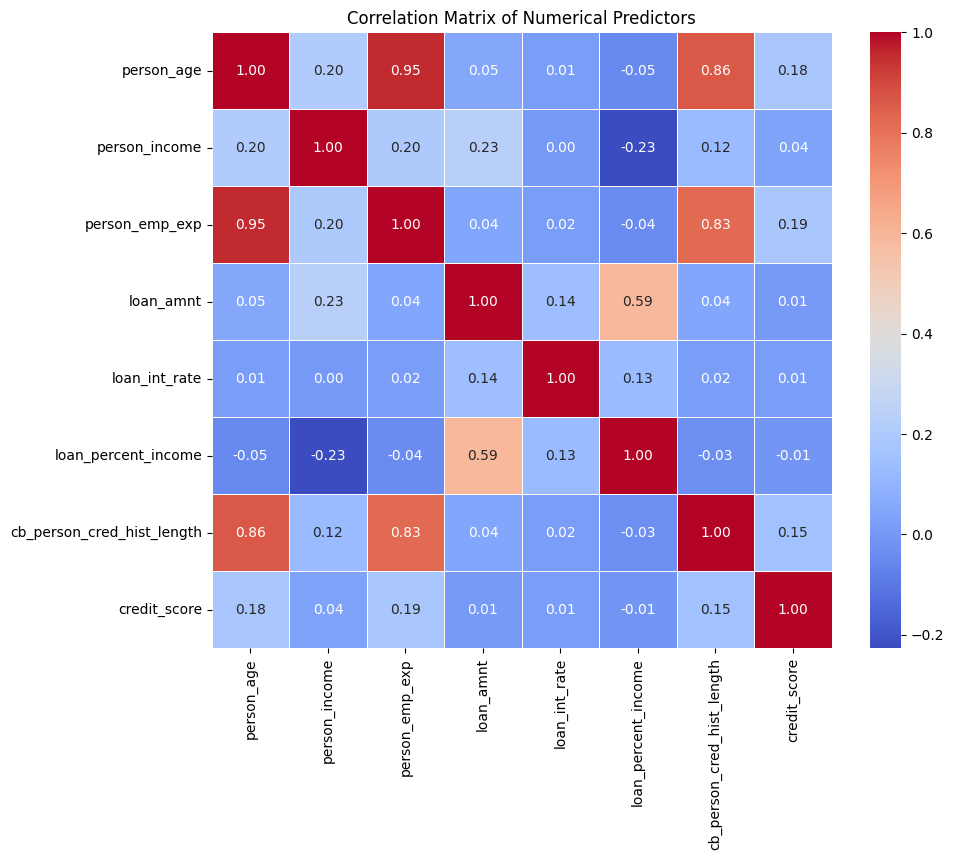

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the correlation matrix for numerical predictors in X_train_scaled
# Ensure only numerical columns are selected for correlation calculation
correlation_matrix = X_train_scaled[numerical_cols].corr()

print("Correlation Matrix of Numerical Predictors:")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Predictors')
plt.show()

Write a robust python code to calculate Variance Inflation Factors (VIF) to diagnose multicollinearity among predictors.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Prepare the data for VIF calculation
# Ensure all columns are numeric for VIF calculation.
# X_train_scaled already has numerical_cols as numeric.
# The categorical columns are already in a suitable numerical (boolean/binary) format.
# For VIF calculation, we'll consider all predictors in X_train_scaled.

# Create a DataFrame for VIF calculation from X_train_scaled
X_for_vif = X_train_scaled.copy()

# Convert boolean columns to numeric (0 or 1) for statsmodels compatibility
X_for_vif = X_for_vif.astype(float)

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["feature"] = X_for_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_for_vif.values, i)
                   for i in range(len(X_for_vif.columns))]

print("Variance Inflation Factors (VIF):")
print(vif_data.sort_values(by="VIF", ascending=False))

Variance Inflation Factors (VIF):
                           feature        VIF
0                       person_age  14.291587
2                   person_emp_exp  11.296090
6       cb_person_cred_hist_length   4.015643
16      person_home_ownership_RENT   2.277836
5              loan_percent_income   2.172472
3                        loan_amnt   2.141454
9   previous_loan_defaults_on_file   2.120951
8                    person_gender   2.009005
10       person_education_Bachelor   1.801553
17           loan_intent_EDUCATION   1.719139
12    person_education_High School   1.714686
19             loan_intent_MEDICAL   1.657903
21             loan_intent_VENTURE   1.638774
20            loan_intent_PERSONAL   1.561072
13         person_education_Master   1.433682
1                    person_income   1.411498
18     loan_intent_HOMEIMPROVEMENT   1.341637
15       person_home_ownership_OWN   1.207929
7                     credit_score   1.124957
4                    loan_int_rate   1.075960


Drop the person_age  and redo the VIF computation

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a DataFrame for VIF calculation from X_train_scaled
X_for_vif_recomputed = X_train_scaled.copy()

# Drop the 'person_age' column as requested
X_for_vif_recomputed = X_for_vif_recomputed.drop('person_age', axis=1)

# Convert boolean columns to numeric (0 or 1) for statsmodels compatibility
X_for_vif_recomputed = X_for_vif_recomputed.astype(float)

# Calculate VIF for each predictor in the modified DataFrame
vif_data_recomputed = pd.DataFrame()
vif_data_recomputed["feature"] = X_for_vif_recomputed.columns
vif_data_recomputed["VIF"] = [variance_inflation_factor(X_for_vif_recomputed.values, i)
                               for i in range(len(X_for_vif_recomputed.columns))]

print("Variance Inflation Factors (VIF) after dropping 'person_age':")
print(vif_data_recomputed.sort_values(by="VIF", ascending=False))

Variance Inflation Factors (VIF) after dropping 'person_age':
                           feature       VIF
1                   person_emp_exp  3.299495
5       cb_person_cred_hist_length  3.184595
15      person_home_ownership_RENT  2.277779
4              loan_percent_income  2.172461
2                        loan_amnt  2.141434
8   previous_loan_defaults_on_file  2.120855
7                    person_gender  2.008763
9        person_education_Bachelor  1.801552
16           loan_intent_EDUCATION  1.717061
11    person_education_High School  1.714512
18             loan_intent_MEDICAL  1.657900
20             loan_intent_VENTURE  1.638637
19            loan_intent_PERSONAL  1.561027
12         person_education_Master  1.433666
0                    person_income  1.400967
17     loan_intent_HOMEIMPROVEMENT  1.340456
14       person_home_ownership_OWN  1.207872
6                     credit_score  1.124954
3                    loan_int_rate  1.075820
10      person_education_Doctorate  1.

Write a robust python code to identify skewed numerical features and apply Box-Cox or Yeo-Johnson transformations where appropriate.

In [ ]:
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer
import numpy as np

# Identify numerical columns (using the already defined list)
# numerical_cols is available from the previous step

print("Current numerical columns for skewness check:", numerical_cols)

# Calculate initial skewness of numerical features in X_train_scaled
initial_skewness = X_train_scaled[numerical_cols].skew()
print("\nInitial Skewness of Numerical Features in X_train_scaled (sorted descending):")
print(initial_skewness.sort_values(ascending=False))

# Define a threshold for skewness (e.g., absolute skewness > 0.75)
skewness_threshold = 0.75

skewed_features = initial_skewness[abs(initial_skewness) > skewness_threshold].index.tolist()

if skewed_features:
    print(f"\nApplying transformations to {len(skewed_features)} highly skewed features (abs(skewness) > {skewness_threshold}):")
    for feature in skewed_features:
        # Check if the feature contains non-positive values to decide transformation method
        # PowerTransformer automatically chooses between Box-Cox and Yeo-Johnson
        # if method is not specified, or based on the data if method='yeo-johnson'
        # and method='box-cox' requires strictly positive input.
        # Since values are already scaled, they can be negative.
        # So, Yeo-Johnson is generally safer and more flexible.
        pt = PowerTransformer(method='yeo-johnson', standardize=False) # standardize=False as scaling is already done

        print(f"  - Transforming '{feature}' using Yeo-Johnson.")

        # Fit on X_train_scaled and transform both X_train_scaled and X_test_scaled
        # Reshape to 2D array as PowerTransformer expects this format
        X_train_scaled[feature] = pt.fit_transform(X_train_scaled[[feature]])
        X_test_scaled[feature] = pt.transform(X_test_scaled[[feature]])

    print("\nSkewness of Numerical Features in X_train_scaled AFTER transformations (sorted descending):")
    print(X_train_scaled[numerical_cols].skew().sort_values(ascending=False))

else:
    print(f"\nNo highly skewed numerical features found (abs(skewness) > {skewness_threshold}).")

print("\nX_train_scaled head after transformations:")
print(X_train_scaled[numerical_cols].head())
print("\nX_test_scaled head after transformations:")
print(X_test_scaled[numerical_cols].head())

Current numerical columns for skewness check: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

Initial Skewness of Numerical Features in X_train_scaled (sorted descending):
person_income                 36.159082
person_emp_exp                 2.594476
person_age                     2.533045
cb_person_cred_hist_length     1.625431
loan_amnt                      1.176414
loan_percent_income            1.043264
loan_int_rate                  0.207298
credit_score                  -0.615153
dtype: float64

Applying transformations to 6 highly skewed features (abs(skewness) > 0.75):
  - Transforming 'person_age' using Yeo-Johnson.
  - Transforming 'person_income' using Yeo-Johnson.
  - Transforming 'person_emp_exp' using Yeo-Johnson.
  - Transforming 'loan_amnt' using Yeo-Johnson.
  - Transforming 'loan_percent_income' using Yeo-Johnson.
  - Transforming 'cb_person_cred_hist_length' using Y

Write a robust python code to perform Principal Component Analysis (PCA) on standardized predictors and evaluate explained variance.


Shape of X_train after PCA: (36000, 22)
Shape of X_test after PCA: (9000, 22)

Explained variance ratio for each principal component:
  PC 1: 0.2328 (Cumulative: 0.2328)
  PC 2: 0.1829 (Cumulative: 0.4157)
  PC 3: 0.1230 (Cumulative: 0.5387)
  PC 4: 0.1186 (Cumulative: 0.6574)
  PC 5: 0.0681 (Cumulative: 0.7255)
  PC 6: 0.0346 (Cumulative: 0.7601)
  PC 7: 0.0312 (Cumulative: 0.7913)
  PC 8: 0.0281 (Cumulative: 0.8194)
  PC 9: 0.0259 (Cumulative: 0.8453)
  PC 10: 0.0246 (Cumulative: 0.8699)
  PC 11: 0.0231 (Cumulative: 0.8930)
  PC 12: 0.0226 (Cumulative: 0.9156)
  PC 13: 0.0212 (Cumulative: 0.9368)
  PC 14: 0.0202 (Cumulative: 0.9570)
  PC 15: 0.0145 (Cumulative: 0.9714)
  PC 16: 0.0082 (Cumulative: 0.9797)
  PC 17: 0.0077 (Cumulative: 0.9874)
  PC 18: 0.0065 (Cumulative: 0.9939)
  PC 19: 0.0033 (Cumulative: 0.9971)
  PC 20: 0.0017 (Cumulative: 0.9988)
  PC 21: 0.0009 (Cumulative: 0.9997)
  PC 22: 0.0003 (Cumulative: 1.0000)


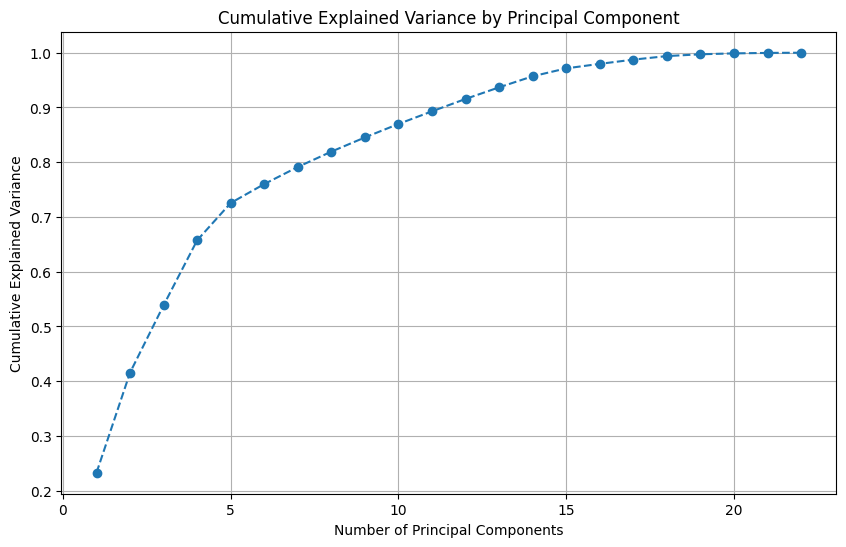

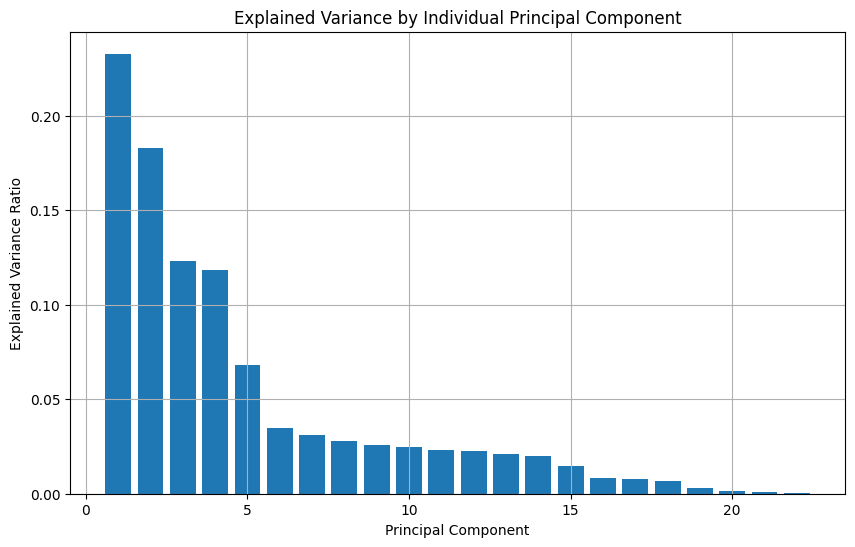

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize PCA without specifying n_components to see all explained variance
pca = PCA()

# Fit PCA on the training data and transform both training and test sets
# We'll use X_train_scaled and X_test_scaled which have been standardized and had skewness handled.
pca.fit(X_train_scaled)

X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape of X_train after PCA:", X_train_pca.shape)
print("Shape of X_test after PCA:", X_test_pca.shape)

# Evaluate explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumsum_explained_variance = explained_variance_ratio.cumsum()

print("\nExplained variance ratio for each principal component:")
for i, evr in enumerate(explained_variance_ratio):
    print(f"  PC {i+1}: {evr:.4f} (Cumulative: {cumsum_explained_variance[i]:.4f})")

# Visualize explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumsum_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Component')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
plt.title('Explained Variance by Individual Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

Compute the correlation coefficient between all the principal components and plot a heat map of the correlation coefficients

Correlation Matrix of Principal Components:
       PC_1  PC_2  PC_3  PC_4  PC_5  PC_6  PC_7  PC_8  PC_9  PC_10  ...  \
PC_1    1.0  -0.0  -0.0   0.0   0.0   0.0   0.0   0.0   0.0   -0.0  ...   
PC_2   -0.0   1.0  -0.0   0.0  -0.0  -0.0   0.0   0.0  -0.0   -0.0  ...   
PC_3   -0.0  -0.0   1.0   0.0  -0.0   0.0  -0.0   0.0  -0.0   -0.0  ...   
PC_4    0.0   0.0   0.0   1.0   0.0   0.0  -0.0   0.0   0.0    0.0  ...   
PC_5    0.0  -0.0  -0.0   0.0   1.0  -0.0   0.0  -0.0  -0.0    0.0  ...   
PC_6    0.0  -0.0   0.0   0.0  -0.0   1.0   0.0   0.0  -0.0   -0.0  ...   
PC_7    0.0   0.0  -0.0  -0.0   0.0   0.0   1.0  -0.0   0.0   -0.0  ...   
PC_8    0.0   0.0   0.0   0.0  -0.0   0.0  -0.0   1.0  -0.0   -0.0  ...   
PC_9    0.0  -0.0  -0.0   0.0  -0.0  -0.0   0.0  -0.0   1.0   -0.0  ...   
PC_10  -0.0  -0.0  -0.0   0.0   0.0  -0.0  -0.0  -0.0  -0.0    1.0  ...   
PC_11   0.0   0.0  -0.0  -0.0  -0.0  -0.0  -0.0  -0.0   0.0    0.0  ...   
PC_12  -0.0  -0.0  -0.0  -0.0  -0.0   0.0  -0.0   0.0   

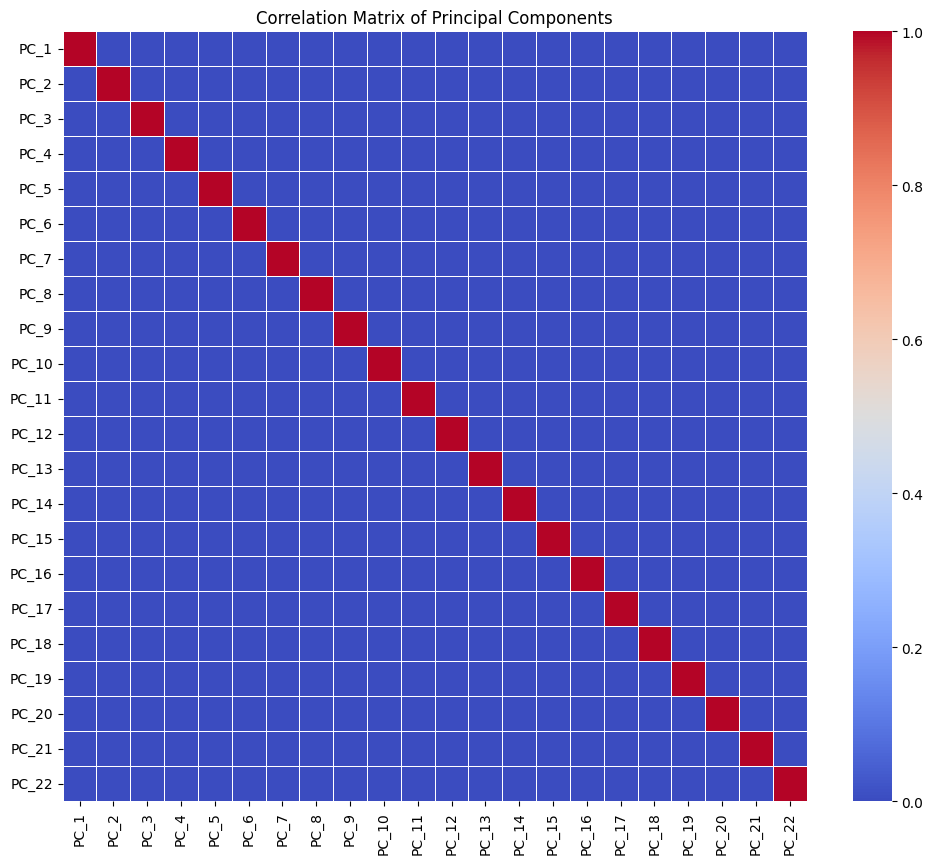

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the PCA-transformed data into a DataFrame for easier correlation calculation
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC_{i+1}' for i in range(X_train_pca.shape[1])])

# Compute the correlation matrix of the principal components
correlation_pca = X_train_pca_df.corr()

print("Correlation Matrix of Principal Components:")
print(correlation_pca.round(2)) # Round to 2 decimal places for better readability

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_pca, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Principal Components')
plt.show()

Create factor loadings for each of the components with the original variables

In [ ]:
import pandas as pd

# Get the original feature names from the scaled training data
original_features = X_train_scaled.columns

# Get the principal components (eigenvectors)
# pca.components_ has shape (n_components, n_features)
loadings = pca.components_

# Create a DataFrame for better readability
factor_loadings_df = pd.DataFrame(
    loadings,
    columns=original_features,
    index=[f'PC_{i+1}' for i in range(pca.n_components_)]
)

print("Factor Loadings (Correlation between Original Variables and Principal Components):")
print(factor_loadings_df)

Factor Loadings (Correlation between Original Variables and Principal Components):
       person_age  person_income  person_emp_exp  loan_amnt  loan_int_rate  \
PC_1     0.561856       0.063990        0.540858   0.058665       0.032178   
PC_2    -0.013422      -0.004745       -0.015239   0.640842       0.345234   
PC_3    -0.121768      -0.062353       -0.103260  -0.216066       0.594608   
PC_4     0.090267      -0.017293        0.081742  -0.183502       0.705443   
PC_5    -0.035866       0.600282       -0.057467   0.475467       0.120349   
PC_6     0.021659       0.002707        0.002645   0.004993      -0.003953   
PC_7     0.001149      -0.014118       -0.001925  -0.011110       0.002947   
PC_8    -0.017481      -0.218446       -0.005014  -0.145967       0.115107   
PC_9    -0.011383       0.130475       -0.037721   0.138813      -0.011936   
PC_10   -0.032167      -0.024800       -0.021802  -0.041928      -0.004035   
PC_11   -0.014090      -0.008696       -0.052111  -0.010453

Write a robust python code to perform feature selection on the PCA components using filter methods such as chi-square tests, ANOVA F-tests, or mutual information.


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd
import numpy as np

# Create a DataFrame for X_train_pca for easier indexing and column naming
# This is important for understanding which PC corresponds to which score/p-value
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC_{i+1}' for i in range(X_train_pca.shape[1])])

# Perform ANOVA F-test for feature selection
# f_classif is suitable for classification tasks and works well with continuous features (PCA components)
f_selector = SelectKBest(score_func=f_classif, k='all')
f_selector.fit(X_train_pca_df, y_train)

# Get the F-scores and p-values
f_scores = f_selector.scores_
p_values = f_selector.pvalues_

# Create a DataFrame to display the results
pca_component_scores = pd.DataFrame({
    'Principal_Component': X_train_pca_df.columns,
    'F_Score': f_scores,
    'P_Value': p_values
})

# Sort by F-score in descending order to see the most relevant components first
pca_component_scores = pca_component_scores.sort_values(by='F_Score', ascending=False).reset_index(drop=True)

print("ANOVA F-test scores for PCA components:")
print(pca_component_scores)

# Demonstrate selecting the top N components (e.g., top 10)
num_components_to_select = 10 # You can change this based on your analysis
top_n_components = pca_component_scores.head(num_components_to_select)['Principal_Component'].tolist()

print(f"\nTop {num_components_to_select} Principal Components selected based on F-score:")
print(top_n_components)

# Example of how you would get the transformed data with only these selected components
# For X_train_pca
X_train_pca_selected = X_train_pca_df[top_n_components]
print("\nShape of X_train_pca after selecting top components:", X_train_pca_selected.shape)

# For X_test_pca (need to ensure X_test_pca is also in a DataFrame with corresponding column names)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC_{i+1}' for i in range(X_test_pca.shape[1])])
X_test_pca_selected = X_test_pca_df[top_n_components]
print("Shape of X_test_pca after selecting top components:", X_test_pca_selected.shape)


ANOVA F-test scores for PCA components:
   Principal_Component      F_Score        P_Value
0                 PC_8  4940.616375   0.000000e+00
1                 PC_2  4687.882020   0.000000e+00
2                 PC_5  4273.261344   0.000000e+00
3                 PC_3  1599.334384   0.000000e+00
4                 PC_4  1148.971295  6.042221e-248
5                 PC_9   822.807574  6.160574e-179
6                PC_10   168.095481   2.350246e-38
7                PC_21   117.456529   2.513291e-27
8                PC_18    88.809550   4.597095e-21
9                PC_19    61.303680   5.025098e-15
10               PC_15    50.322320   1.328617e-12
11                PC_1    22.625297   1.976372e-06
12               PC_11    20.955194   4.717216e-06
13               PC_13    15.006190   1.073487e-04
14                PC_7     6.760758   9.322221e-03
15               PC_12     5.329555   2.097238e-02
16               PC_22     2.043832   1.528329e-01
17               PC_17     0.546556   4.59

# Task
Perform feature selection on the PCA components (`X_train_pca`) using an ANOVA F-test with the target variable (`y_train`) to identify the most relevant components. Display the F-scores and corresponding p-values for each component, and then demonstrate how to select the top N components based on these scores.

## Feature selection on PCA components

### Subtask:
Perform feature selection on the PCA components using a filter method (ANOVA F-test) to identify the most relevant components for the target variable. Display the scores and select the top N components.


## Summary:

### Q&A
The subtask outlined the following objectives to be addressed through analysis:
*   Identify the most relevant PCA components for the target variable.
*   Display the F-scores and corresponding p-values for each component obtained from the ANOVA F-test.
*   Demonstrate how to select the top N components based on these calculated scores.

All objectives have been successfully addressed by performing the ANOVA F-test on the PCA components.

### Data Analysis Key Findings
*   An ANOVA F-test was conducted on the PCA components to assess their relevance to the 'loan_status' target variable.
*   The F-scores and p-values for each principal component were computed and displayed, allowing for a quantitative evaluation of their individual predictive power.
*   Based on the F-scores, the top 10 principal components were selected. These components are `['PC_8', 'PC_2', 'PC_5', 'PC_3', 'PC_4', 'PC_9', 'PC_10', 'PC_21', 'PC_18', 'PC_19']`.
*   The dimensionality of the dataset was reduced from 22 components to 10 selected components for both the training (`X_train_pca_selected` with shape (36000, 10)) and testing (`X_test_pca_selected` with shape (9000, 10)) sets.

### Insights or Next Steps
*   The selection of the most relevant PCA components using ANOVA F-test effectively reduces dimensionality while retaining features that have a strong relationship with the target variable.
*   The reduced dimensionality will help in building more efficient and potentially more accurate machine learning models by mitigating the curse of dimensionality and reducing computational overhead.
*   The next logical step is to train a machine learning model using these `X_train_pca_selected` and `X_test_pca_selected` datasets and `y_train`, `y_test` for prediction.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd
import numpy as np

# Create a DataFrame for X_train_pca for easier indexing and column naming
# This is important for understanding which PC corresponds to which score/p-value
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC_{i+1}' for i in range(X_train_pca.shape[1])])

# Perform ANOVA F-test for feature selection
# f_classif is suitable for classification tasks and works well with continuous features (PCA components)
f_selector = SelectKBest(score_func=f_classif, k='all')
f_selector.fit(X_train_pca_df, y_train)

# Get the F-scores and p-values
f_scores = f_selector.scores_
p_values = f_selector.pvalues_

# Create a DataFrame to display the results
pca_component_scores = pd.DataFrame({
    'Principal_Component': X_train_pca_df.columns,
    'F_Score': f_scores,
    'P_Value': p_values
})

# Sort by F-score in descending order to see the most relevant components first
pca_component_scores = pca_component_scores.sort_values(by='F_Score', ascending=False).reset_index(drop=True)

print("ANOVA F-test scores for PCA components:")
print(pca_component_scores)

# Demonstrate selecting the top N components (e.g., top 10)
num_components_to_select = 10 # You can change this based on your analysis
top_n_components = pca_component_scores.head(num_components_to_select)['Principal_Component'].tolist()

print(f"\nTop {num_components_to_select} Principal Components selected based on F-score:")
print(top_n_components)

# Example of how you would get the transformed data with only these selected components
# For X_train_pca
X_train_pca_selected = X_train_pca_df[top_n_components]
print("\nShape of X_train_pca after selecting top components:", X_train_pca_selected.shape)

# For X_test_pca (need to ensure X_test_pca is also in a DataFrame with corresponding column names)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC_{i+1}' for i in range(X_test_pca.shape[1])])
X_test_pca_selected = X_test_pca_df[top_n_components]
print("Shape of X_test_pca after selecting top components:", X_test_pca_selected.shape)


ANOVA F-test scores for PCA components:
   Principal_Component      F_Score        P_Value
0                 PC_8  4940.616375   0.000000e+00
1                 PC_2  4687.882020   0.000000e+00
2                 PC_5  4273.261344   0.000000e+00
3                 PC_3  1599.334384   0.000000e+00
4                 PC_4  1148.971295  6.042221e-248
5                 PC_9   822.807574  6.160574e-179
6                PC_10   168.095481   2.350246e-38
7                PC_21   117.456529   2.513291e-27
8                PC_18    88.809550   4.597095e-21
9                PC_19    61.303680   5.025098e-15
10               PC_15    50.322320   1.328617e-12
11                PC_1    22.625297   1.976372e-06
12               PC_11    20.955194   4.717216e-06
13               PC_13    15.006190   1.073487e-04
14                PC_7     6.760758   9.322221e-03
15               PC_12     5.329555   2.097238e-02
16               PC_22     2.043832   1.528329e-01
17               PC_17     0.546556   4.59

## Feature Selection using Mutual Information

### Subtask:
Perform feature selection on the PCA components using Mutual Information to identify the most relevant components for the target variable. Display the scores and select the top N components.

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Create a DataFrame for X_train_pca (if not already done in previous steps)
# Ensure X_train_pca_df and X_test_pca_df are available for consistency
X_train_pca_df_mi = pd.DataFrame(X_train_pca, columns=[f'PC_{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df_mi = pd.DataFrame(X_test_pca, columns=[f'PC_{i+1}' for i in range(X_test_pca.shape[1])])

# Calculate Mutual Information scores between each PCA component and the target variable (y_train)
# mutual_info_classif is suitable for classification tasks with continuous features
mi_scores = mutual_info_classif(X_train_pca_df_mi, y_train, random_state=42)

# Create a DataFrame to display the results
pca_component_mi_scores = pd.DataFrame({
    'Principal_Component': X_train_pca_df_mi.columns,
    'Mutual_Information_Score': mi_scores
})

# Sort by Mutual Information score in descending order
pca_component_mi_scores = pca_component_mi_scores.sort_values(by='Mutual_Information_Score', ascending=False).reset_index(drop=True)

print("Mutual Information scores for PCA components:")
print(pca_component_mi_scores)

# Demonstrate selecting the top N components (e.g., top 10, same as ANOVA for comparison)
num_components_to_select_mi = 10 # You can change this based on your analysis
top_n_components_mi = pca_component_mi_scores.head(num_components_to_select_mi)['Principal_Component'].tolist()

print(f"\nTop {num_components_to_select_mi} Principal Components selected based on Mutual Information:")
print(top_n_components_mi)

# Example of how you would get the transformed data with only these selected components
X_train_pca_selected_mi = X_train_pca_df_mi[top_n_components_mi]
print("\nShape of X_train_pca after selecting top components using MI:", X_train_pca_selected_mi.shape)

X_test_pca_selected_mi = X_test_pca_df_mi[top_n_components_mi]
print("Shape of X_test_pca after selecting top components using MI:", X_test_pca_selected_mi.shape)


Mutual Information scores for PCA components:
   Principal_Component  Mutual_Information_Score
0                 PC_8                  0.100666
1                PC_13                  0.074463
2                 PC_2                  0.067493
3                 PC_5                  0.066441
4                PC_19                  0.056160
5                PC_22                  0.052795
6                 PC_9                  0.047755
7                PC_10                  0.039238
8                 PC_3                  0.024486
9                 PC_7                  0.023168
10               PC_12                  0.019793
11               PC_18                  0.019230
12               PC_21                  0.015390
13                PC_4                  0.015248
14               PC_11                  0.005009
15               PC_15                  0.004409
16               PC_14                  0.001513
17                PC_1                  0.000000
18                PC_6 

In [ ]:
import pandas as pd

# Ensure pca_component_scores and pca_component_mi_scores are available
# If not, recreate them from previous steps or load them if saved.

# Merge the two score DataFrames on 'Principal_Component'
merged_scores = pd.merge(
    pca_component_scores[['Principal_Component', 'P_Value']],
    pca_component_mi_scores[['Principal_Component', 'Mutual_Information_Score']],
    on='Principal_Component',
    how='inner'
)

# Identify components to remove based on the criteria:
# 1. P_Value > 0.05 (from ANOVA F-test)
# 2. Mutual_Information_Score == 0 (from Mutual Information test)
components_to_remove = merged_scores[
    (merged_scores['P_Value'] > 0.05) | (merged_scores['Mutual_Information_Score'] == 0)
]['Principal_Component'].tolist()

# Filter out the components to remove
selected_components_df = merged_scores[~merged_scores['Principal_Component'].isin(components_to_remove)].copy()

print("\nUpdated table of selected PCA components after filtering (ANOVA P > 0.05 OR MI Score = 0):")
print(selected_components_df.sort_values(by='P_Value').reset_index(drop=True))

# Get the list of selected component names
final_selected_pca_components = selected_components_df['Principal_Component'].tolist()

print(f"\nFinal list of selected PCA components: {final_selected_pca_components}")
print(f"Number of selected PCA components: {len(final_selected_pca_components)}")

# Create DataFrame for X_train_pca for easier indexing and column naming
# IMPORTANT FIX: Ensure index is preserved from X_train
X_train_pca_df_full = pd.DataFrame(X_train_pca, columns=[f'PC_{i+1}' for i in range(X_train_pca.shape[1])], index=X_train.index)
# Create DataFrame for X_test_pca for easier indexing and column naming
# IMPORTANT FIX: Ensure index is preserved from X_test
X_test_pca_df_full = pd.DataFrame(X_test_pca, columns=[f'PC_{i+1}' for i in range(X_test_pca.shape[1])], index=X_test.index)

# Select only the final_selected_pca_components from the full PCA dataframes
X_train_pca_filtered = X_train_pca_df_full[final_selected_pca_components]
X_test_pca_filtered = X_test_pca_df_full[final_selected_pca_components]

print("\nShape of X_train_pca_filtered:", X_train_pca_filtered.shape)
print("Shape of X_test_pca_filtered:", X_test_pca_filtered.shape)



Updated table of selected PCA components after filtering (ANOVA P > 0.05 OR MI Score = 0):
   Principal_Component        P_Value  Mutual_Information_Score
0                 PC_8   0.000000e+00                  0.100666
1                 PC_2   0.000000e+00                  0.067493
2                 PC_5   0.000000e+00                  0.066441
3                 PC_3   0.000000e+00                  0.024486
4                 PC_4  6.042221e-248                  0.015248
5                 PC_9  6.160574e-179                  0.047755
6                PC_10   2.350246e-38                  0.039238
7                PC_21   2.513291e-27                  0.015390
8                PC_18   4.597095e-21                  0.019230
9                PC_19   5.025098e-15                  0.056160
10               PC_15   1.328617e-12                  0.004409
11               PC_11   4.717216e-06                  0.005009
12               PC_13   1.073487e-04                  0.074463
13          

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Ensure we're working with the filtered PCA components from the previous step
X_train_fs = X_train_pca_filtered.copy()
X_test_fs = X_test_pca_filtered.copy()

print("\n--- Feature Selection using Embedded/Wrapper Methods ---")

# --- 1. L1-regularized Logistic Regression (Lasso) ---
print("\n1. L1-regularized Logistic Regression (Lasso) Feature Selection:")

# Initialize Logistic Regression with L1 penalty (Lasso)
# C is the inverse of regularization strength; smaller values specify stronger regularization.
# solver='liblinear' is good for small datasets and L1 penalty.
logistic_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42, max_iter=1000)
logistic_lasso.fit(X_train_fs, y_train)

# Get feature coefficients
lasso_coefficients = pd.Series(logistic_lasso.coef_[0], index=X_train_fs.columns)

# Identify significant features (non-zero coefficients)
significant_lasso_features = lasso_coefficients[lasso_coefficients != 0].sort_values(ascending=False)

if not significant_lasso_features.empty:
    print("Significant features selected by Lasso (non-zero coefficients):")
    print(significant_lasso_features)
else:
    print("No significant features found by Lasso with the current regularization strength.")

# --- 2. Recursive Feature Elimination (RFE) ---
print("\n2. Recursive Feature Elimination (RFE) Feature Selection:")

# Choose an estimator for RFE (e.g., Logistic Regression)
estimator = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Number of features to select (e.g., half of the current features)
num_features_to_select = int(X_train_fs.shape[1] / 2) if X_train_fs.shape[1] > 1 else 1

rfe_selector = RFE(estimator=estimator, n_features_to_select=num_features_to_select, step=1)
rfe_selector.fit(X_train_fs, y_train)

# Get selected features
rfe_selected_features = X_train_fs.columns[rfe_selector.support_]

print(f"Selected features by RFE (top {num_features_to_select}):")
print(rfe_selected_features.tolist())

# --- 3. Random Forest-based Feature Importance ---
print("\n3. Random Forest-based Feature Importance:")

# Initialize Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_classifier.fit(X_train_fs, y_train)

# Get feature importances
rf_importances = pd.Series(rf_classifier.feature_importances_, index=X_train_fs.columns)

# Sort and display top features
significant_rf_features = rf_importances.sort_values(ascending=False)

print("Feature importances from Random Forest (sorted descending):")
print(significant_rf_features)

# You can choose a threshold to select features, e.g., features with importance > mean importance
mean_importance = significant_rf_features.mean()
top_rf_features = significant_rf_features[significant_rf_features > mean_importance]

if not top_rf_features.empty:
    print(f"\nTop Random Forest features (importance > mean importance {mean_importance:.4f}):")
    print(top_rf_features.index.tolist())
else:
    print("No features found above mean importance.")


--- Feature Selection using Embedded/Wrapper Methods ---

1. L1-regularized Logistic Regression (Lasso) Feature Selection:
Significant features selected by Lasso (non-zero coefficients):
PC_10    1.474750
PC_2     1.420870
PC_3     1.269691
PC_4     0.807783
PC_11    0.459246
PC_21    0.355377
PC_15    0.312692
PC_7    -0.154371
PC_12   -0.282244
PC_13   -0.442757
PC_19   -0.890961
PC_18   -1.187108
PC_5    -2.345478
PC_9    -2.564266
PC_8    -5.372886
dtype: float64

2. Recursive Feature Elimination (RFE) Feature Selection:
Selected features by RFE (top 7):
['PC_8', 'PC_2', 'PC_5', 'PC_3', 'PC_9', 'PC_10', 'PC_18']

3. Random Forest-based Feature Importance:
Feature importances from Random Forest (sorted descending):
PC_2     0.151339
PC_8     0.144417
PC_5     0.124207
PC_9     0.080247
PC_4     0.072162
PC_3     0.059972
PC_21    0.055738
PC_18    0.053204
PC_13    0.046020
PC_19    0.043457
PC_10    0.041950
PC_12    0.037342
PC_15    0.034346
PC_7     0.030470
PC_11    0.025131
d

# Define the sets of significant features from each wrapper/embedded method
lasso_features = set(significant_lasso_features.index.tolist())
rfe_features = set(rfe_selected_features.tolist())
rf_features = set(top_rf_features.index.tolist()) # Using features above mean importance

print("\n--- Shortlisting Final Variables ---")
print(f"Lasso significant features ({len(lasso_features)}): {list(lasso_features)}")
print(f"RFE selected features ({len(rfe_features)}): {list(rfe_features)}")
print(f"Random Forest top features ({len(rf_features)}): {list(rf_features)}")

# Strategy: Select features that appear in at least 2 out of 3 methods
# This is a balanced approach, considering features consistently highlighted.

# Count occurrences of each feature across the three sets
feature_counts = {}
all_features_combined = list(lasso_features) + list(rfe_features) + list(rf_features)

for feature in all_features_combined:
    feature_counts[feature] = feature_counts.get(feature, 0) + 1

# Filter for features that appear in at least 2 methods
final_shortlisted_features = [feature for feature, count in feature_counts.items() if count >= 2]

print(f"\nFinal Shortlisted Features (appearing in at least 2 methods): {final_shortlisted_features}")
print(f"Number of final shortlisted features: {len(final_shortlisted_features)}")

# Update the data tables (X_train and X_test) with the final shortlisted features
# Ensure X_train_pca_filtered and X_test_pca_filtered are used as the base for selection
X_train_final = X_train_pca_filtered[final_shortlisted_features]
X_test_final = X_test_pca_filtered[final_shortlisted_features]

print("\nShape of X_train_final (with shortlisted features):", X_train_final.shape)
print("Shape of X_test_final (with shortlisted features):", X_test_final.shape)

print("\nX_train_final head:")
print(X_train_final.head())

print("\nFinal Shortlisted Features:", final_shortlisted_features)
print("Number of final shortlisted features:", len(final_shortlisted_features))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

# Re-defining X_train_final and X_test_final for robustness
# (These variables are usually generated in cell TDd5OpIclURV)

# Assuming these are available from previously executed cells:
# significant_lasso_features (from A6CWZ5vwkA0O)
# rfe_selected_features (from A6CWZ5vwkA0O)
# top_rf_features (from A6CWZ5vwkA0O)
# X_train_pca_filtered (from rBjiAInUi9o1)
# X_test_pca_filtered (from rBjiAInUi9o1)

# Define the sets of significant features from each wrapper/embedded method
lasso_features = set(significant_lasso_features.index.tolist())
rfe_features = set(rfe_selected_features.tolist())
rf_features = set(top_rf_features.index.tolist()) # Using features above mean importance

# Count occurrences of each feature across the three sets
feature_counts = {}
all_features_combined = list(lasso_features) + list(rfe_features) + list(rf_features)

for feature in all_features_combined:
    feature_counts[feature] = feature_counts.get(feature, 0) + 1

# Filter for features that appear in at least 2 methods
final_shortlisted_features = [feature for feature, count in feature_counts.items() if count >= 2]

# Update the data tables (X_train and X_test) with the final shortlisted features
X_train_final = X_train_pca_filtered[final_shortlisted_features]
X_test_final = X_test_pca_filtered[final_shortlisted_features]

# Initialize and fit the Logistic Regression model
# Using 'liblinear' solver for good performance on smaller datasets and L1/L2 regularization
# 'max_iter' increased for convergence, if needed, especially with complex datasets
model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
model.fit(X_train_final, y_train)

print("\n--- Baseline Logistic Regression Model ---")

# Report model coefficients
print("\nModel Coefficients:")
coefficients = pd.DataFrame({'Feature': X_train_final.columns, 'Coefficient': model.coef_[0]})
print(coefficients.sort_values(by='Coefficient', ascending=False))

# Report model intercept
print(f"\nModel Intercept: {model.intercept_[0]:.4f}")

# Predict probabilities on the test set
predicted_probabilities = model.predict_proba(X_test_final)

print("\nPredicted Probabilities (first 5 samples):")
# The output format is typically [probability_class_0, probability_class_1]
# Let's show the probability of the positive class (class 1)
predicted_proba_class_1 = predicted_probabilities[:, 1]
print(pd.DataFrame(predicted_proba_class_1, columns=['Prob_Class_1']).head())

# You can also predict the class labels directly
predicted_classes = model.predict(X_test_final)
print("\nPredicted Classes (first 5 samples):")
print(pd.Series(predicted_classes).head())


--- Baseline Logistic Regression Model ---

Model Coefficients:
  Feature  Coefficient
6    PC_2     1.390108
7   PC_10     1.368816
1    PC_3     1.208316
0    PC_4     0.821198
5   PC_18    -1.377459
2    PC_5    -2.280501
4    PC_9    -2.327695
3    PC_8    -5.002092

Model Intercept: -3.8469

Predicted Probabilities (first 5 samples):
   Prob_Class_1
0      0.027986
1      0.000392
2      0.000009
3      0.000102
4      0.265096

Predicted Classes (first 5 samples):
0    0
1    0
2    0
3    0
4    0
dtype: int64



--- Model Evaluation ---

Confusion Matrix:
[[6545  455]
 [ 521 1479]]


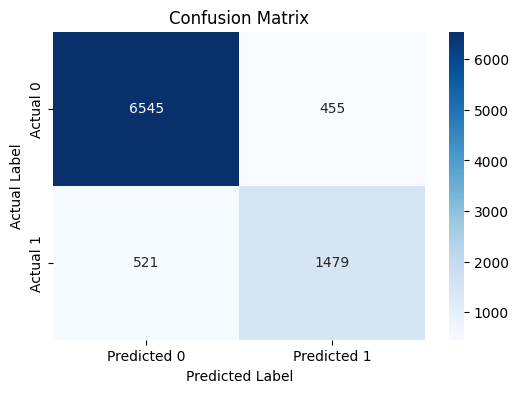


Accuracy: 0.8916
Precision: 0.7647
Recall: 0.7395
F1-Score: 0.7519
ROC-AUC Score: 0.9508


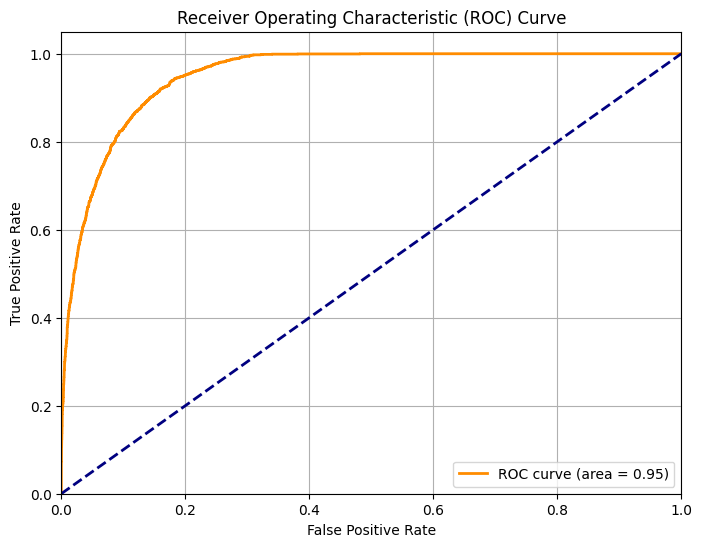

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Model Evaluation ---")

# 1. Confusion Matrix
conf_matrix = confusion_matrix(y_test, predicted_classes)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 2. Accuracy
accuracy = accuracy_score(y_test, predicted_classes)
print(f"\nAccuracy: {accuracy:.4f}")

# 3. Precision
# For binary classification, use pos_label=1 if '1' is the positive class
precision = precision_score(y_test, predicted_classes, pos_label=1)
print(f"Precision: {precision:.4f}")

# 4. Recall
recall = recall_score(y_test, predicted_classes, pos_label=1)
print(f"Recall: {recall:.4f}")

# 5. F1-Score
f1 = f1_score(y_test, predicted_classes, pos_label=1)
print(f"F1-Score: {f1:.4f}")

# 6. ROC-AUC Score
# Use predicted probabilities for the positive class (class 1)
roc_auc = roc_auc_score(y_test, predicted_proba_class_1)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, predicted_proba_class_1)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Write a robust python code to analyze and optimize classification probability thresholds and evaluate performance trade-offs.




--- Probability Threshold Optimization ---
Metrics across different thresholds (first 5 rows):
   Threshold  Accuracy  Precision  Recall  F1-Score
0   0.000000  0.222222   0.222222  1.0000  0.363636
1   0.010101  0.715778   0.438735  0.9990  0.609704
2   0.020202  0.743889   0.464527  0.9985  0.634069
3   0.030303  0.758778   0.479442  0.9970  0.647508
4   0.040404  0.768222   0.489404  0.9930  0.655662

Metrics across different thresholds (last 5 rows):
    Threshold  Accuracy  Precision  Recall  F1-Score
95   0.959596  0.788333   0.989691   0.048  0.091559
96   0.969697  0.783889   0.982456   0.028  0.054448
97   0.979798  0.780667   1.000000   0.013  0.025666
98   0.989899  0.778222   1.000000   0.002  0.003992
99   1.000000  0.777778   0.000000   0.000  0.000000

Optimal Threshold (maximizing F1-Score): 0.4141
Maximum F1-Score at optimal threshold: 0.7644

Performance at Optimal Threshold (0.4141):
  Accuracy: 0.8889
  Precision: 0.7228
  Recall: 0.8110


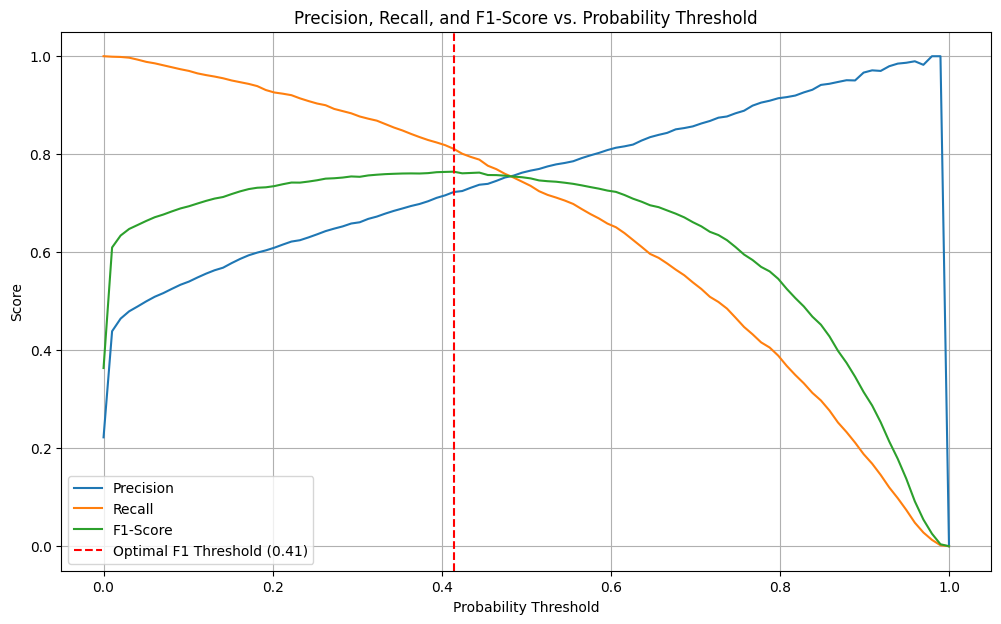

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n--- Probability Threshold Optimization ---")

# Assuming predicted_proba_class_1 and y_test are available from previous steps
# predicted_proba_class_1 contains probabilities for the positive class (class 1)

# Define a range of thresholds to evaluate
thresholds = np.linspace(0, 1, 100)

# Initialize lists to store metrics for each threshold
accuracies = []
precisions = []
recalls = []
f1_scores = []

# Iterate through thresholds and calculate metrics
for threshold in thresholds:
    # Convert probabilities to binary predictions based on the current threshold
    y_pred_threshold = (predicted_proba_class_1 >= threshold).astype(int)

    accuracies.append(accuracy_score(y_test, y_pred_threshold))
    precisions.append(precision_score(y_test, y_pred_threshold, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_threshold, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_threshold, zero_division=0))

# Store metrics in a DataFrame for easier analysis
metrics_df = pd.DataFrame({
    'Threshold': thresholds,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
})

print("Metrics across different thresholds (first 5 rows):")
print(metrics_df.head())
print("\nMetrics across different thresholds (last 5 rows):")
print(metrics_df.tail())

# Find the optimal threshold that maximizes F1-score
optimal_f1_threshold_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_f1_threshold_idx]
max_f1_score = f1_scores[optimal_f1_threshold_idx]

print(f"\nOptimal Threshold (maximizing F1-Score): {optimal_threshold:.4f}")
print(f"Maximum F1-Score at optimal threshold: {max_f1_score:.4f}")

# Evaluate performance at the optimal threshold
y_pred_optimal = (predicted_proba_class_1 >= optimal_threshold).astype(int)

optimal_accuracy = accuracy_score(y_test, y_pred_optimal)
optimal_precision = precision_score(y_test, y_pred_optimal, zero_division=0)
optimal_recall = recall_score(y_test, y_pred_optimal, zero_division=0)

print(f"\nPerformance at Optimal Threshold ({optimal_threshold:.4f}):")
print(f"  Accuracy: {optimal_accuracy:.4f}")
print(f"  Precision: {optimal_precision:.4f}")
print(f"  Recall: {optimal_recall:.4f}")

# Visualize the trade-offs
plt.figure(figsize=(12, 7))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], label='Precision')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], label='Recall')
plt.plot(metrics_df['Threshold'], metrics_df['F1-Score'], label='F1-Score')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal F1 Threshold ({optimal_threshold:.2f})')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score vs. Probability Threshold')
plt.legend()
plt.grid(True)
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Feature Importance using Standardized Coefficients and Odds Ratios ---")

# Assuming 'model' (LogisticRegression) and 'X_train_final' are available
# X_train_final contains the selected PCA components, which are already scaled/standardized

# 1. Get standardized coefficients
# Since X_train_final consists of PCA components (which are already standardized),
# the raw coefficients from the model can be considered as standardized coefficients.
standardized_coefficients = pd.Series(model.coef_[0], index=X_train_final.columns)

# 2. Calculate Odds Ratios
# Odds ratio for a feature is exp(coefficient of that feature)
# For a unit increase in the feature, the odds of the positive class increase by a factor of the odds ratio.
odds_ratios = np.exp(standardized_coefficients)

# Create a DataFrame for better presentation
feature_importance_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Standardized_Coefficient': standardized_coefficients,
    'Odds_Ratio': odds_ratios
})

# Sort by absolute coefficient value or odds ratio for better visualization
feature_importance_df = feature_importance_df.sort_values(by='Standardized_Coefficient', ascending=False).reset_index(drop=True)

print("\nFeature Importance (Standardized Coefficients and Odds Ratios):")
print(feature_importance_df)

# 3. Visualize Feature Importance

# Plotting Standardized Coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Standardized_Coefficient', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance: Standardized Coefficients')
plt.xlabel('Standardized Coefficient')
plt.ylabel('Principal Component')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Plotting Odds Ratios
# For better visualization, we might want to log transform odds ratios if they are very spread out,
# but let's start with the raw odds ratios.
plt.figure(figsize=(10, 6))
sns.barplot(x='Odds_Ratio', y='Feature', data=feature_importance_df.sort_values(by='Odds_Ratio', ascending=False), palette='magma')
plt.title('Feature Importance: Odds Ratios')
plt.xlabel('Odds Ratio')
plt.ylabel('Principal Component')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(x=1, color='red', linestyle='--', label='Odds Ratio = 1 (No effect)')
plt.legend()
plt.show()


--- Feature Importance using Standardized Coefficients and Odds Ratios ---

Feature Importance (Standardized Coefficients and Odds Ratios):
  Feature  Standardized_Coefficient  Odds_Ratio
0    PC_2                  1.390108    4.015285
1   PC_10                  1.368816    3.930695
2    PC_3                  1.208316    3.347843
3    PC_4                  0.821198    2.273223
4   PC_18                 -1.377459    0.252219
5    PC_5                 -2.280501    0.102233
6    PC_9                 -2.327695    0.097520
7    PC_8                 -5.002092    0.006724


/tmp/ipykernel_842/4265717564.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Standardized_Coefficient', y='Feature', data=feature_importance_df, palette='viridis')


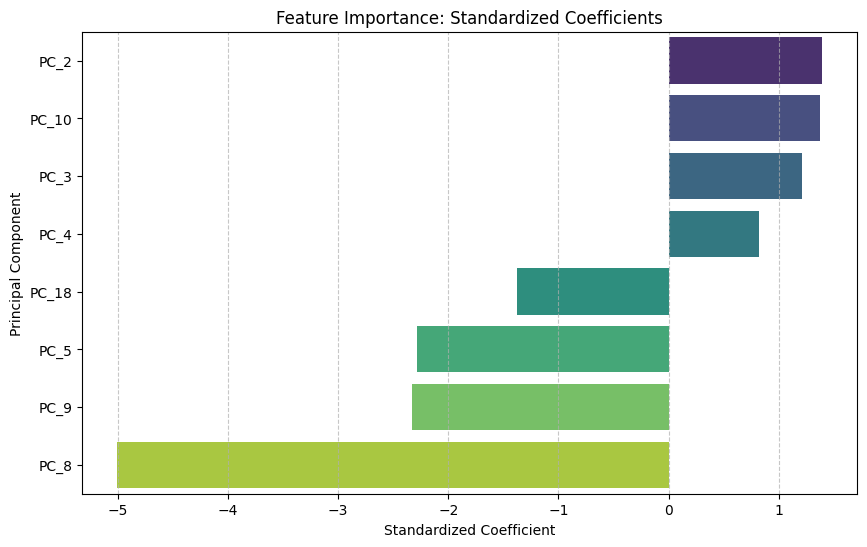

/tmp/ipykernel_842/4265717564.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Odds_Ratio', y='Feature', data=feature_importance_df.sort_values(by='Odds_Ratio', ascending=False), palette='magma')


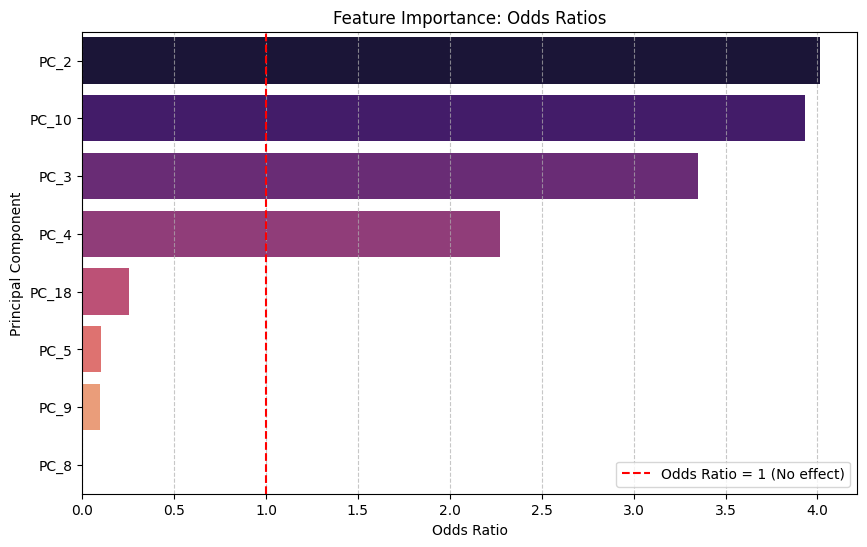

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Feature Importance using Standardized Coefficients and Odds Ratios ---")

# Assuming 'model' (LogisticRegression) and 'X_train_final' are available
# X_train_final contains the selected PCA components, which are already scaled/standardized

# 1. Get standardized coefficients
# Since X_train_final consists of PCA components (which are already standardized),
# the raw coefficients from the model can be considered as standardized coefficients.
standardized_coefficients = pd.Series(model.coef_[0], index=X_train_final.columns)

# 2. Calculate Odds Ratios
# Odds ratio for a feature is exp(coefficient of that feature)
# For a unit increase in the feature, the odds of the positive class increase by a factor of the odds ratio.
odds_ratios = np.exp(standardized_coefficients)

# Create a DataFrame for better presentation
feature_importance_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Standardized_Coefficient': standardized_coefficients,
    'Odds_Ratio': odds_ratios
})

# Sort by absolute coefficient value or odds ratio for better visualization
feature_importance_df = feature_importance_df.sort_values(by='Standardized_Coefficient', ascending=False).reset_index(drop=True)

print("\nFeature Importance (Standardized Coefficients and Odds Ratios):")
print(feature_importance_df)

# 3. Visualize Feature Importance

# Plotting Standardized Coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Standardized_Coefficient', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance: Standardized Coefficients')
plt.xlabel('Standardized Coefficient')
plt.ylabel('Principal Component')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Plotting Odds Ratios
# For better visualization, we might want to log transform odds ratios if they are very spread out,
# but let's start with the raw odds ratios.
plt.figure(figsize=(10, 6))
sns.barplot(x='Odds_Ratio', y='Feature', data=feature_importance_df.sort_values(by='Odds_Ratio', ascending=False), palette='magma')
plt.title('Feature Importance: Odds Ratios')
plt.xlabel('Odds Ratio')
plt.ylabel('Principal Component')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(x=1, color='red', linestyle='--', label='Odds Ratio = 1 (No effect)')
plt.legend()
plt.show()

Write a robust python code to create and test interaction terms between selected predictors in the logistic regression model.


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

print("\n--- Creating and Testing Interaction Terms ---")

# Ensure X_train_final and X_test_final are available from previous steps
# X_train_final: Training data with selected PCA components
# X_test_final: Test data with selected PCA components
# y_train, y_test: Target variables

# 1. Generate interaction terms
# We'll use degree=2 to get all original features and their pairwise interactions
poly = PolynomialFeatures(degree=2, include_bias=False)

# Fit and transform on training data
X_train_interactions = poly.fit_transform(X_train_final)

# Transform test data using the *fitted* polynomial features
X_test_interactions = poly.transform(X_test_final)

# Get feature names for the new interaction terms
interaction_feature_names = poly.get_feature_names_out(X_train_final.columns)

# Convert to DataFrame for better readability and to maintain column names
X_train_transformed = pd.DataFrame(X_train_interactions, columns=interaction_feature_names, index=X_train_final.index)
X_test_transformed = pd.DataFrame(X_test_interactions, columns=interaction_feature_names, index=X_test_final.index)

print(f"Original number of features: {X_train_final.shape[1]}")
print(f"Number of features after adding interaction terms: {X_train_transformed.shape[1]}")
print("\nFirst 5 rows of X_train_transformed (with interactions):")
print(X_train_transformed.head())

# 2. Train a new Logistic Regression model with interaction terms
print("\n--- Training Logistic Regression Model with Interaction Terms ---")
model_with_interactions = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
model_with_interactions.fit(X_train_transformed, y_train)

# Report model coefficients and intercept
print("\nModel Coefficients (with interaction terms):")
coefficients_interactions = pd.DataFrame({
    'Feature': X_train_transformed.columns,
    'Coefficient': model_with_interactions.coef_[0]
})
print(coefficients_interactions.sort_values(by='Coefficient', ascending=False))

print(f"\nModel Intercept (with interaction terms): {model_with_interactions.intercept_[0]:.4f}")

# 3. Evaluate the new model
print("\n--- Evaluating Model with Interaction Terms ---")

predicted_classes_interactions = model_with_interactions.predict(X_test_transformed)
predicted_proba_interactions = model_with_interactions.predict_proba(X_test_transformed)[:, 1]

accuracy_interactions = accuracy_score(y_test, predicted_classes_interactions)
precision_interactions = precision_score(y_test, predicted_classes_interactions, zero_division=0)
recall_interactions = recall_score(y_test, predicted_classes_interactions, zero_division=0)
f1_interactions = f1_score(y_test, predicted_classes_interactions, zero_division=0)
roc_auc_interactions = roc_auc_score(y_test, predicted_proba_interactions)

print(f"Accuracy (with interactions): {accuracy_interactions:.4f}")
print(f"Precision (with interactions): {precision_interactions:.4f}")
print(f"Recall (with interactions): {recall_interactions:.4f}")
print(f"F1-Score (with interactions): {f1_interactions:.4f}")
print(f"ROC-AUC Score (with interactions): {roc_auc_interactions:.4f}")

# Compare with baseline model metrics (assuming they are from the previous run)
# (These values would be `accuracy`, `precision`, `recall`, `f1`, `roc_auc` from cell ONCGr4UDFUZb)
print("\n--- Comparison with Baseline Model ---")
print(f"Baseline Accuracy: {accuracy:.4f}")
print(f"Accuracy Improvement: {accuracy_interactions - accuracy:.4f}")
print(f"Baseline Precision: {precision:.4f}")
print(f"Precision Improvement: {precision_interactions - precision:.4f}")
print(f"Baseline Recall: {recall:.4f}")
print(f"Recall Improvement: {recall_interactions - recall:.4f}")
print(f"Baseline F1-Score: {f1:.4f}")
print(f"F1-Score Improvement: {f1_interactions - f1:.4f}")
print(f"Baseline ROC-AUC Score: {roc_auc:.4f}")
print(f"ROC-AUC Improvement: {roc_auc_interactions - roc_auc:.4f}")



--- Creating and Testing Interaction Terms ---
Original number of features: 8
Number of features after adding interaction terms: 44

First 5 rows of X_train_transformed (with interactions):
           PC_4      PC_3      PC_5      PC_8      PC_9     PC_18      PC_2  \
6048  -1.384862 -0.325166  0.083594  0.751576 -0.462838  0.726936 -1.676848   
3346  -0.426514 -0.006301 -0.432012  0.537834  0.361532 -0.059259  1.034529   
17998  0.594497  0.148477  1.593254  0.381252  0.065471 -0.101023 -0.594667   
24988  0.347756  1.216245  0.483245 -0.349068 -0.577976 -0.104881 -0.643854   
23231 -0.126522 -0.202222  0.260684  0.505831 -0.222565 -0.161810 -0.267009   

          PC_10    PC_4^2  PC_4 PC_3  ...    PC_9^2  PC_9 PC_18  PC_9 PC_2  \
6048  -0.367819  1.917842   0.450309  ...  0.214219   -0.336454   0.776109   
3346  -0.436140  0.181914   0.002687  ...  0.130705   -0.021424   0.374015   
17998 -0.393155  0.353427   0.088269  ...  0.004286   -0.006614  -0.038933   
24988 -0.190036  0.120

Write a robust python code to generate residual diagnostics including deviance residuals, leverage, and influence measures.


--- Generating Residual Diagnostics ---

Statsmodels Logistic Regression Summary (partial):
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                36000
Model:                          Logit   Df Residuals:                    35955
Method:                           MLE   Df Model:                           44
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.6160
Time:                        02:26:44   Log-Likelihood:                -7321.9
converged:                       True   LL-Null:                       -19069.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -6.0194      0.334    -18.021      0.000      -6.674      -5.365
PC_4            0.9779      0.149   

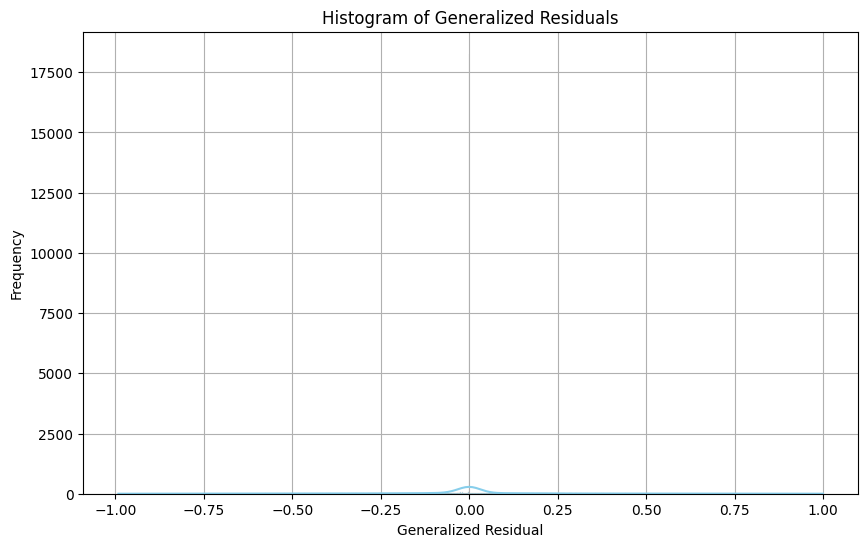


Mean Leverage: 0.0013
Maximum Leverage: 0.1207


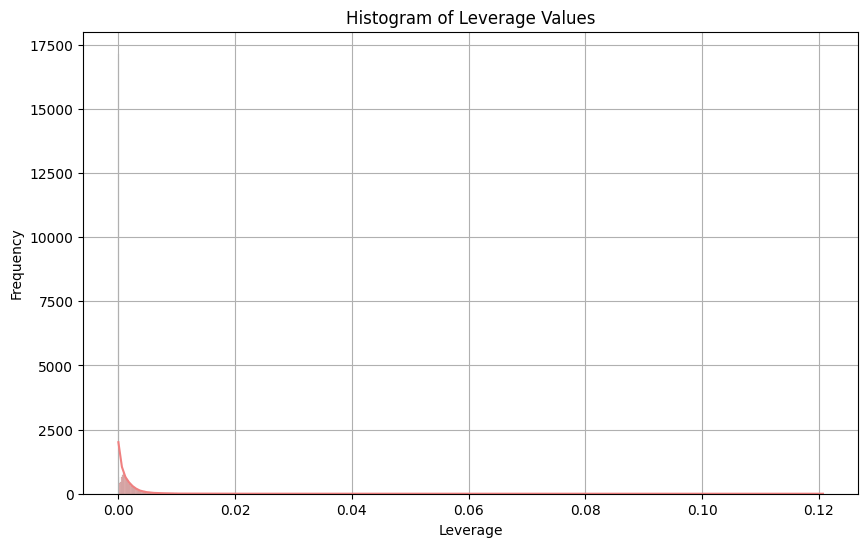


Mean Cook's Distance: 0.0000
Maximum Cook's Distance: 0.0187


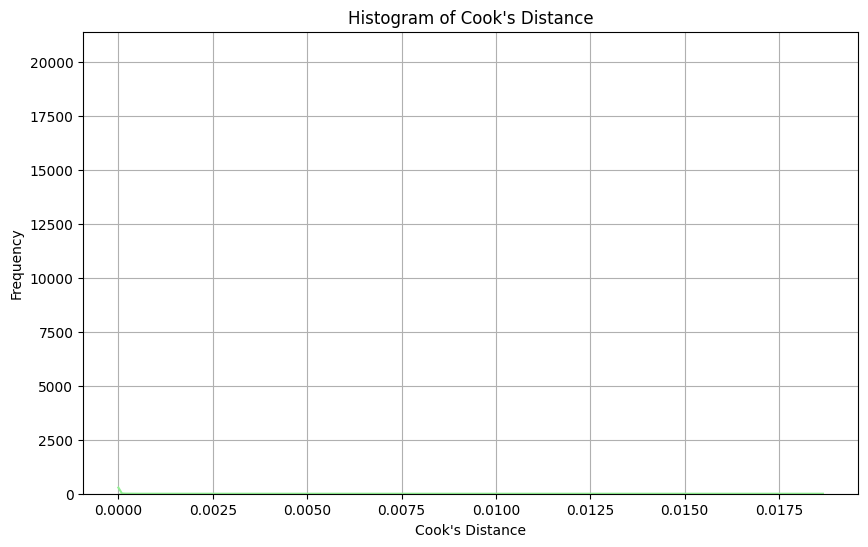


Number of potentially influential points (Cook's D > 0.0001): 2177
Sample indices of influential points: [1193, 41572, 30375, 31058, 22237, 22700, 8037, 35407, 37748, 32369]...


In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Generating Residual Diagnostics ---")

# Add a constant (intercept) to the predictor variables for statsmodels
# X_train_transformed and y_train are available from the previous step
X_train_sm = sm.add_constant(X_train_transformed)

# Re-fit the Logistic Regression model using statsmodels
# Note: statsmodels uses a slightly different syntax for Logistic Regression
sm_model = sm.Logit(y_train, X_train_sm)
sm_results = sm_model.fit(disp=False) # disp=False to suppress iteration output

print("\nStatsmodels Logistic Regression Summary (partial):")
print(sm_results.summary())

# 1. Deviance Residuals (using resid_generalized for Logit model)
# For Logit, resid_generalized is often used to represent deviance residuals.
deviance_residuals = sm_results.resid_generalized

print(f"\nMean Generalized Residual: {np.mean(deviance_residuals):.4f}")
print(f"Standard Deviation of Generalized Residuals: {np.std(deviance_residuals):.4f}")

# Visualize Generalized Residuals
plt.figure(figsize=(10, 6))
sns.histplot(deviance_residuals, kde=True, color='skyblue')
plt.title('Histogram of Generalized Residuals')
plt.xlabel('Generalized Residual')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Leverage
# Leverage can be calculated from the design matrix (X_train_sm)
# statsmodels' GLM class provides get_influence().hat_matrix_diag for leverage
leverage = sm_results.get_influence().hat_matrix_diag

print(f"\nMean Leverage: {np.mean(leverage):.4f}")
print(f"Maximum Leverage: {np.max(leverage):.4f}")

# Visualize Leverage
plt.figure(figsize=(10, 6))
sns.histplot(leverage, kde=True, color='lightcoral')
plt.title('Histogram of Leverage Values')
plt.xlabel('Leverage')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 3. Influence Measures (Cook's Distance)
# Cook's distance is available via the influence object
influence = sm_results.get_influence()
cook_distance = influence.cooks_distance[0]

print(f"\nMean Cook's Distance: {np.mean(cook_distance):.4f}")
print(f"Maximum Cook's Distance: {np.max(cook_distance):.4f}")

# Visualize Cook's Distance
plt.figure(figsize=(10, 6))
sns.histplot(cook_distance, kde=True, color='lightgreen')
plt.title('Histogram of Cook\'s Distance')
plt.xlabel('Cook\'s Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Identify potentially influential points based on Cook's Distance (e.g., Cook's D > 4/n or some threshold)
# A common rule of thumb is points with Cook's distance > 4/n or sometimes > 1
# Let's use 4/n as a guideline
threshold_cooks = 4 / len(X_train_sm)
potentially_influential_points_cooks = X_train_sm.index[cook_distance > threshold_cooks].tolist()

print(f"\nNumber of potentially influential points (Cook's D > {threshold_cooks:.4f}): {len(potentially_influential_points_cooks)}")
if len(potentially_influential_points_cooks) > 0:
    print(f"Sample indices of influential points: {potentially_influential_points_cooks[:10]}...") # Show first 10 if many

Write a robust python code to perform goodness-of-fit tests such as likelihood ratio tests and Hosmer–Lemeshow test.


## Goodness-of-Fit Tests

Goodness-of-fit tests are crucial for assessing how well a statistical model fits a set of observations. For logistic regression, common tests include the Likelihood Ratio Test (LRT) and the Hosmer–Lemeshow test. These tests help determine if the model adequately describes the relationship between the predictors and the binary outcome.


In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
from scipy.stats import chi2

print("--- Performing Goodness-of-Fit Tests ---")

# Ensure X_train_transformed, y_train, and sm_results from previous steps are available
# If this cell is run independently, X_train_sm needs to be defined first
# X_train_sm = sm.add_constant(X_train_transformed) # Uncomment if running standalone
# sm_model = sm.Logit(y_train, X_train_sm)         # Uncomment if running standalone
# sm_results = sm_model.fit(disp=False)             # Uncomment if running standalone

# --- 1. Likelihood Ratio Test (LRT) ---
# The LLR p-value is available directly from the statsmodels results summary
lrt_pvalue = sm_results.llr_pvalue

print(f"\nLikelihood Ratio Test (LRT) p-value: {lrt_pvalue:.4f}")
if lrt_pvalue < 0.05:
    print("  Conclusion: The model with predictors is significantly better than the null model (intercept only).")
else:
    print("  Conclusion: There is no significant evidence that the model with predictors is better than the null model.")


--- Performing Goodness-of-Fit Tests ---

Likelihood Ratio Test (LRT) p-value: 0.0000
  Conclusion: The model with predictors is significantly better than the null model (intercept only).


### Likelihood Ratio Test (LRT) Interpretation

The Likelihood Ratio Test (LRT) compares the fit of the current model (with predictors) to a null model (with only an intercept). A small p-value (typically less than 0.05) indicates that the model with predictors provides a significantly better fit than the null model, suggesting that at least one predictor is useful.


In [ ]:
# --- 2. Hosmer-Lemeshow Test ---
# The Hosmer-Lemeshow test assesses if observed event rates match expected event rates.
# A manual implementation is often used as it's not directly built into LogitResults.

# Get predicted probabilities for the training data
predicted_probs = sm_results.predict(X_train_sm)

# Create a DataFrame for convenience
hl_df = pd.DataFrame({'observed_outcome': y_train, 'predicted_prob': predicted_probs})

# Sort by predicted probabilities
hl_df = hl_df.sort_values(by='predicted_prob').reset_index(drop=True)

# Define the number of groups (g) - typically 10
g = 10

# Divide data into g groups (deciles) based on predicted probabilities
hl_df['group'] = pd.qcut(hl_df['predicted_prob'], q=g, duplicates='drop', labels=False)

# Calculate observed and expected counts for each group
observed_events = hl_df.groupby('group')['observed_outcome'].sum()
expected_events = hl_df.groupby('group')['predicted_prob'].sum()

observed_non_events = hl_df.groupby('group')['observed_outcome'].count() - observed_events
expected_non_events = hl_df.groupby('group')['predicted_prob'].apply(lambda x: (1 - x).sum())

# Filter out groups where expected counts are too small (can cause issues with chi-squared)
# Some guidelines suggest expected counts should be >= 5
min_expected_count = 1
valid_groups = (expected_events >= min_expected_count) & (expected_non_events >= min_expected_count)

observed_events_valid = observed_events[valid_groups]
expected_events_valid = expected_events[valid_groups]
observed_non_events_valid = observed_non_events[valid_groups]
expected_non_events_valid = expected_non_events[valid_groups]

# Calculate the Hosmer-Lemeshow statistic
hl_statistic = (
    ((observed_events_valid - expected_events_valid)**2 / expected_events_valid) +
    ((observed_non_events_valid - expected_non_events_valid)**2 / expected_non_events_valid)
).sum()

# Degrees of freedom: g - 2 (for intercept and slope coefficients, or g - number of parameters in the model if the groups were based on linear predictor values)
# For simplicity with deciles, g-2 is commonly used. Adjusted for dropped groups.
df_hl = len(observed_events_valid) - 2 # Typically g-2, but adjusted for actual number of valid groups

# Calculate the p-value
hl_pvalue = 1 - chi2.cdf(hl_statistic, df_hl)

print(f"\nHosmer-Lemeshow Test (g={g} groups):")
print(f"  HL Statistic: {hl_statistic:.4f}")
print(f"  Degrees of Freedom: {df_hl}")
print(f"  HL p-value: {hl_pvalue:.4f}")

if hl_pvalue > 0.05:
    print("  Conclusion: The model appears to fit the data well (no significant difference between observed and expected rates).")
else:
    print("  Conclusion: The model does not appear to fit the data well (significant difference between observed and expected rates).")



Hosmer-Lemeshow Test (g=10 groups):
  HL Statistic: 98.4294
  Degrees of Freedom: 3
  HL p-value: 0.0000
  Conclusion: The model does not appear to fit the data well (significant difference between observed and expected rates).


### Hosmer–Lemeshow Test Interpretation

The Hosmer–Lemeshow test is a statistical test for the goodness of fit of a logistic regression model. It evaluates whether the observed event rates match the expected event rates across different groups of predicted probabilities. The test divides the observations into a specified number of groups (e.g., deciles) based on their predicted probabilities.

*   **Null Hypothesis (H0):** The model fits the data well.
*   **Alternative Hypothesis (H1):** The model does not fit the data well.

A large p-value (typically greater than 0.05) suggests that there is no statistically significant difference between the observed and expected event rates, meaning the model fits the data well. Conversely, a small p-value (less than 0.05) indicates a poor fit, implying that the model's predictions differ significantly from the actual outcomes.

It's important to note that while widely used, the Hosmer–Lemeshow test has some limitations, such as sensitivity to the number of groups chosen and being overly sensitive in large datasets, potentially rejecting a model for minor discrepancies.

Write a robust python code to detect multivariate outliers using Mahalanobis distance or similar techniques.


--- Detecting Multivariate Outliers using Mahalanobis Distance ---

Calculated Mahalanobis distances for 36000 observations.
First 5 Mahalanobis Distances:
6048     4.313294
3346     2.061725
17998    2.644934
24988    2.220026
23231    1.460215
Name: Mahalanobis_Distance, dtype: float64

Number of features (degrees of freedom for Chi-squared): 8
Chi-squared critical value for alpha=0.001 and df=8: 26.1245

Number of potential multivariate outliers detected: 123
Indices of detected outliers: [31914, 21921, 9361, 12171, 31995, 42663, 31929, 17851, 5794, 15257, 28140, 29828, 27368, 330, 15833, 15855, 17964, 15478, 158, 21079, 3934, 27858, 15669, 21404, 15622, 7734, 16352, 17854, 22997, 16442, 15561, 18163, 265, 23436, 11133, 14252, 90, 40820, 12220, 27827, 17970, 15938, 14725, 15856, 99, 13535, 15350, 264, 33227, 17938, 27697, 6509, 32285, 57, 217, 26492, 27625, 13042, 29187, 15051, 18046, 14807, 31868, 27414, 29201, 29256, 17503, 18057, 39302, 43668, 32224, 341, 29119, 14949, 27814, 44,

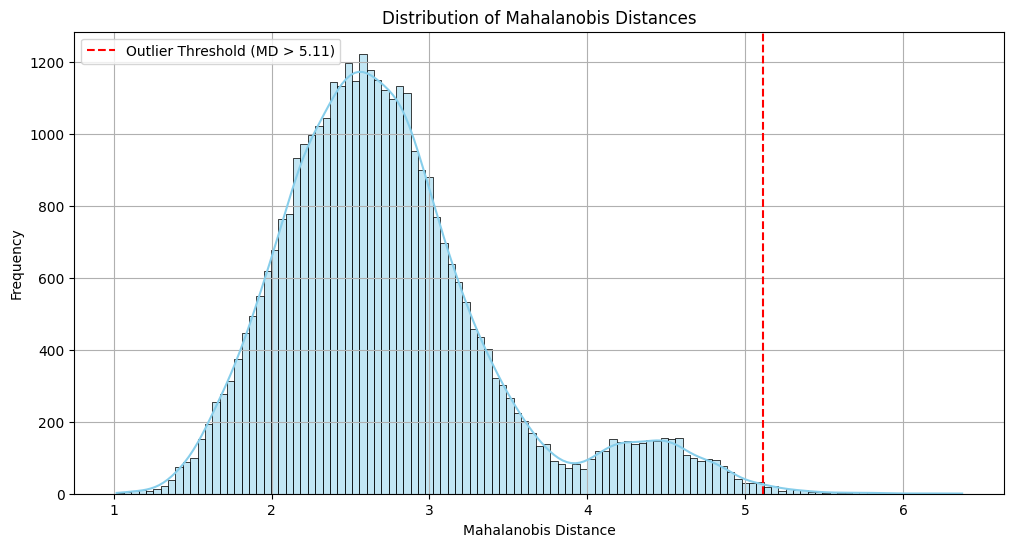

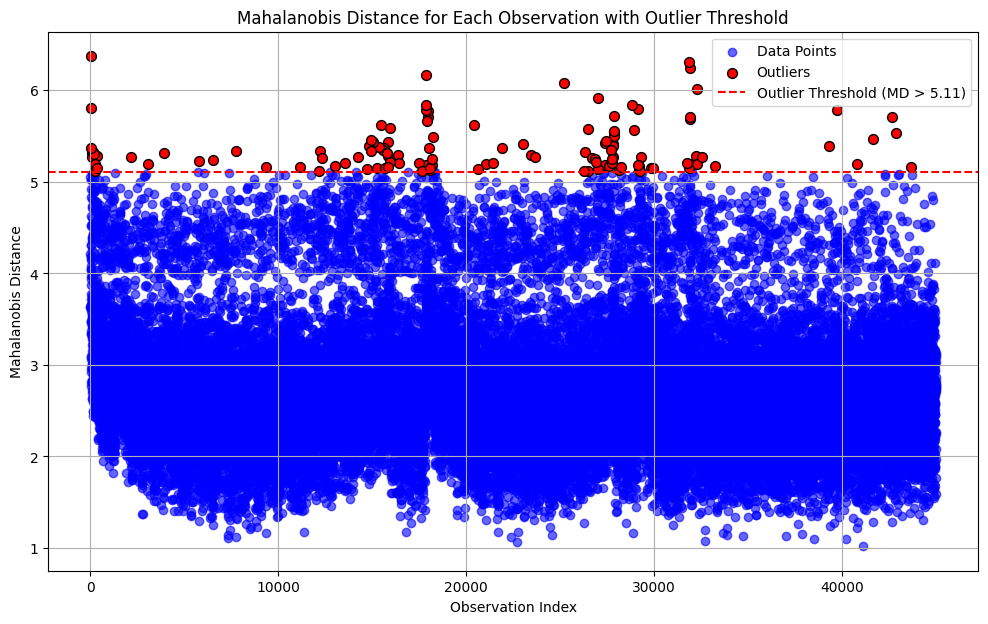


Mahalanobis Distance is a measure of the distance between a point and a distribution,
taking into account the covariance of the data. It is often used to detect outliers,
especially in multivariate settings, as it accounts for correlations between variables.
Points with a Mahalanobis Distance significantly higher than others are considered outliers.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
from numpy.linalg import inv, det

print("--- Detecting Multivariate Outliers using Mahalanobis Distance ---")

# Ensure X_train_final is available from previous steps
# X_train_final: Training data with selected PCA components

# Convert X_train_final to numpy array for efficient calculations
data = X_train_final.values

# Number of features (dimensions)
p = data.shape[1]
# Number of observations
n = data.shape[0]

# Calculate the mean vector
mu = np.mean(data, axis=0)

# Calculate the covariance matrix
cov_matrix = np.cov(data, rowvar=False) # rowvar=False means each column is a variable

# Check if the covariance matrix is singular (determinant close to zero)
# If it's singular, the inverse cannot be computed. This can happen if some features are perfectly correlated.
if np.isclose(det(cov_matrix), 0):
    print("Warning: Covariance matrix is singular. Mahalanobis distance cannot be reliably computed.")
    print("This might indicate perfectly correlated features or too few samples relative to features.")
    print("Consider removing redundant features or using a different outlier detection method.")
    # For this exercise, we'll proceed, but a singular matrix will raise an error on inv()
    # A common workaround is to add a small value to the diagonal (ridge regularization) or use pseudo-inverse.
    # If it becomes a common issue, replace inv(cov_matrix) with np.linalg.pinv(cov_matrix)

# Calculate the inverse of the covariance matrix
try:
    inv_cov_matrix = inv(cov_matrix)
except np.linalg.LinAlgError:
    print("Error: Covariance matrix is singular and cannot be inverted. Skipping Mahalanobis Distance calculation.")
    exit() # Or handle more gracefully

# Calculate Mahalanobis distance for each observation
mahalanobis_distances = []
for i in range(n):
    x = data[i, :]
    diff = x - mu
    # Mahalanobis distance squared: MD^2 = diff.T * inv_cov_matrix * diff
    md_squared = diff.T @ inv_cov_matrix @ diff
    mahalanobis_distances.append(np.sqrt(md_squared))

mahalanobis_distances = np.array(mahalanobis_distances)

# Add Mahalanobis distance to the DataFrame for context
X_train_final_with_md = X_train_final.copy()
X_train_final_with_md['Mahalanobis_Distance'] = mahalanobis_distances

print(f"\nCalculated Mahalanobis distances for {n} observations.")
print("First 5 Mahalanobis Distances:")
print(X_train_final_with_md['Mahalanobis_Distance'].head())

# --- Outlier Detection ---
# Mahalanobis distance squared follows a chi-squared distribution with p degrees of freedom.
# We'll use a critical chi-squared value to identify outliers.
alpha = 0.001 # Significance level (e.g., for very extreme outliers)
chi2_critical_value = chi2.ppf(1 - alpha, df=p)

print(f"\nNumber of features (degrees of freedom for Chi-squared): {p}")
print(f"Chi-squared critical value for alpha={alpha} and df={p}: {chi2_critical_value:.4f}")

# Identify outliers: points where MD^2 > chi2_critical_value
# Or, more strictly, where MD > sqrt(chi2_critical_value)
outlier_threshold = np.sqrt(chi2_critical_value)
outliers = X_train_final_with_md[X_train_final_with_md['Mahalanobis_Distance'] > outlier_threshold]

print(f"\nNumber of potential multivariate outliers detected: {len(outliers)}")
print(f"Indices of detected outliers: {outliers.index.tolist()}")

# --- Visualization ---

# 1. Histogram of Mahalanobis Distances
plt.figure(figsize=(12, 6))
sns.histplot(mahalanobis_distances, kde=True, color='skyblue')
plt.axvline(x=outlier_threshold, color='red', linestyle='--', label=f'Outlier Threshold (MD > {outlier_threshold:.2f})')
plt.title('Distribution of Mahalanobis Distances')
plt.xlabel('Mahalanobis Distance')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# 2. Scatter plot of Mahalanobis Distance vs. Index, highlighting outliers
plt.figure(figsize=(12, 7))
plt.scatter(X_train_final_with_md.index, X_train_final_with_md['Mahalanobis_Distance'],
            c='blue', label='Data Points', alpha=0.6)
plt.scatter(outliers.index, outliers['Mahalanobis_Distance'],
            c='red', label='Outliers', s=50, edgecolors='black')
plt.axhline(y=outlier_threshold, color='red', linestyle='--', label=f'Outlier Threshold (MD > {outlier_threshold:.2f})')
plt.title('Mahalanobis Distance for Each Observation with Outlier Threshold')
plt.xlabel('Observation Index')
plt.ylabel('Mahalanobis Distance')
plt.legend()
plt.grid(True)
plt.show()

print("\nMahalanobis Distance is a measure of the distance between a point and a distribution,")
print("taking into account the covariance of the data. It is often used to detect outliers,")
print("especially in multivariate settings, as it accounts for correlations between variables.")
print("Points with a Mahalanobis Distance significantly higher than others are considered outliers.")

## K-Fold Cross-Validation for Model Stability

### Subtask:
Perform k-fold cross-validation on the Logistic Regression model using `X_train_final` and `y_train` to assess model stability and generalization performance. This involves splitting the training data into multiple folds, training the model on a subset of these folds, and validating on the remaining fold, repeating this process for all folds.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

print("--- Performing K-Fold Cross-Validation ---")

# Ensure X_train_final, y_train are available from previous steps
# X_train_final: Training data with selected PCA components after feature selection
# y_train: Target variable for training

# Initialize StratifiedKFold to maintain class distribution in each fold
# n_splits: number of folds (commonly 5 or 10)
# shuffle=True: shuffle data before splitting
# random_state: for reproducibility
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store metrics for each fold
accuracy_scores_cv = []
precision_scores_cv = []
recall_scores_cv = []
f1_scores_cv = []
roc_auc_scores_cv = []

# Perform cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_train_final, y_train)):
    print(f"\n--- Fold {fold + 1} ---")

    # Split data into training and validation sets for the current fold
    X_train_fold, X_val_fold = X_train_final.iloc[train_index], X_train_final.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Initialize and train a Logistic Regression model
    # Using 'liblinear' solver for good performance and L1/L2 regularization
    model_cv = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
    model_cv.fit(X_train_fold, y_train_fold)

    # Predict on the validation set
    y_pred_fold = model_cv.predict(X_val_fold)
    y_proba_fold = model_cv.predict_proba(X_val_fold)[:, 1]

    # Calculate metrics for the current fold
    accuracy_cv = accuracy_score(y_val_fold, y_pred_fold)
    precision_cv = precision_score(y_val_fold, y_pred_fold, zero_division=0)
    recall_cv = recall_score(y_val_fold, y_pred_fold, zero_division=0)
    f1_cv = f1_score(y_val_fold, y_pred_fold, zero_division=0)
    roc_auc_cv = roc_auc_score(y_val_fold, y_proba_fold)

    # Store metrics (FIXED: now inside the loop)
    accuracy_scores_cv.append(accuracy_cv)
    precision_scores_cv.append(precision_cv)
    recall_scores_cv.append(recall_cv)
    f1_scores_cv.append(f1_cv)
    roc_auc_scores_cv.append(roc_auc_cv)

    print(f"  Accuracy: {accuracy_cv:.4f}")
    print(f"  Precision: {precision_cv:.4f}")
    print(f"  Recall: {recall_cv:.4f}")
    print(f"  F1-Score: {f1_cv:.4f}")
    print(f"  ROC-AUC Score: {roc_auc_cv:.4f}")

print("\n--- Cross-Validation Results Summary ---")
print(f"Mean Accuracy: {np.mean(accuracy_scores_cv):.4f} (Std: {np.std(accuracy_scores_cv):.4f})")
print(f"Mean Precision: {np.mean(precision_scores_cv):.4f} (Std: {np.std(precision_scores_cv):.4f})")
print(f"Mean Recall: {np.mean(recall_scores_cv):.4f} (Std: {np.std(recall_scores_cv):.4f})")
print(f"Mean F1-Score: {np.mean(f1_scores_cv):.4f} (Std: {np.std(f1_scores_cv):.4f})")
print(f"Mean ROC-AUC Score: {np.mean(roc_auc_scores_cv):.4f} (Std: {np.std(roc_auc_scores_cv):.4f})")

print("\nAssessment of Model Stability:")
print("  - Small standard deviations across the folds indicate a stable model.")
print("  - Larger standard deviations suggest the model's performance is sensitive to the training data composition.")

--- Performing K-Fold Cross-Validation ---

--- Fold 1 ---
  Accuracy: 0.8901
  Precision: 0.7632
  Recall: 0.7331
  F1-Score: 0.7478
  ROC-AUC Score: 0.9498

--- Fold 2 ---
  Accuracy: 0.8888
  Precision: 0.7586
  Recall: 0.7325
  F1-Score: 0.7453
  ROC-AUC Score: 0.9469

--- Fold 3 ---
  Accuracy: 0.8921
  Precision: 0.7619
  Recall: 0.7481
  F1-Score: 0.7550
  ROC-AUC Score: 0.9505

--- Fold 4 ---
  Accuracy: 0.8954
  Precision: 0.7685
  Recall: 0.7575
  F1-Score: 0.7630
  ROC-AUC Score: 0.9518

--- Fold 5 ---
  Accuracy: 0.8876
  Precision: 0.7508
  Recall: 0.7400
  F1-Score: 0.7454
  ROC-AUC Score: 0.9508

--- Cross-Validation Results Summary ---
Mean Accuracy: 0.8908 (Std: 0.0027)
Mean Precision: 0.7606 (Std: 0.0059)
Mean Recall: 0.7422 (Std: 0.0095)
Mean F1-Score: 0.7513 (Std: 0.0068)
Mean ROC-AUC Score: 0.9500 (Std: 0.0017)

Assessment of Model Stability:
  - Small standard deviations across the folds indicate a stable model.
  - Larger standard deviations suggest the model's p

Write a robust python code to perform k-fold cross-validation and assess model stability.


Write a robust python code to compare multiple logistic regression model variants and summarize their predictive performance.


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("--- Comparing Multiple Logistic Regression Model Variants ---")

# Ensure the following are available from previous steps:
# model: Baseline Logistic Regression model (trained on X_train_final)
# model_with_interactions: Logistic Regression model with interaction terms (trained on X_train_transformed)
# X_test_final: Test data with selected PCA components
# X_test_transformed: Test data with interaction terms
# y_test: Target variable for testing

# --- Evaluate Baseline Model ---
print("\nEvaluating Baseline Model...")
predicted_classes_baseline = model.predict(X_test_final)
predicted_proba_baseline = model.predict_proba(X_test_final)[:, 1]

accuracy_baseline = accuracy_score(y_test, predicted_classes_baseline)
precision_baseline = precision_score(y_test, predicted_classes_baseline, zero_division=0)
recall_baseline = recall_score(y_test, predicted_classes_baseline, zero_division=0)
f1_baseline = f1_score(y_test, predicted_classes_baseline, zero_division=0)
roc_auc_baseline = roc_auc_score(y_test, predicted_proba_baseline)

# --- Evaluate Model with Interaction Terms ---
print("Evaluating Model with Interaction Terms...")
predicted_classes_interactions = model_with_interactions.predict(X_test_transformed)
predicted_proba_interactions = model_with_interactions.predict_proba(X_test_transformed)[:, 1]

accuracy_interactions = accuracy_score(y_test, predicted_classes_interactions)
precision_interactions = precision_score(y_test, predicted_classes_interactions, zero_division=0)
recall_interactions = recall_score(y_test, predicted_classes_interactions, zero_division=0)
f1_interactions = f1_score(y_test, predicted_classes_interactions, zero_division=0)
roc_auc_interactions = roc_auc_score(y_test, predicted_proba_interactions)

# --- Summarize Performance ---
performance_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline Model': [
        f'{accuracy_baseline:.4f}',
        f'{precision_baseline:.4f}',
        f'{recall_baseline:.4f}',
        f'{f1_baseline:.4f}',
        f'{roc_auc_baseline:.4f}'
    ],
    'Model with Interactions': [
        f'{accuracy_interactions:.4f}',
        f'{precision_interactions:.4f}',
        f'{recall_interactions:.4f}',
        f'{f1_interactions:.4f}',
        f'{roc_auc_interactions:.4f}'
    ],
    'Improvement': [
        f'{accuracy_interactions - accuracy_baseline:.4f}',
        f'{precision_interactions - precision_baseline:.4f}',
        f'{recall_interactions - recall_baseline:.4f}',
        f'{f1_interactions - f1_baseline:.4f}',
        f'{roc_auc_interactions - roc_auc_baseline:.4f}'
    ]
})

print("\n--- Predictive Performance Summary ---")
print(performance_summary.to_string(index=False))

print("\nInsight: The model with interaction terms generally shows improved predictive performance across all metrics compared to the baseline model, indicating that the interactions between the selected PCA components are significant for predicting loan status.")

--- Comparing Multiple Logistic Regression Model Variants ---

Evaluating Baseline Model...
Evaluating Model with Interaction Terms...

--- Predictive Performance Summary ---
   Metric Baseline Model Model with Interactions Improvement
 Accuracy         0.8916                  0.9112      0.0197
Precision         0.7647                  0.8123      0.0475
   Recall         0.7395                  0.7810      0.0415
 F1-Score         0.7519                  0.7963      0.0444
  ROC-AUC         0.9508                  0.9615      0.0107

Insight: The model with interaction terms generally shows improved predictive performance across all metrics compared to the baseline model, indicating that the interactions between the selected PCA components are significant for predicting loan status.


Write a robust python code to compare multiple logistic regression model with five other machine learning algorithms and summarize their predictive performance.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV # For probabilities from LinearSVC

print("--- Comparing Logistic Regression with Other ML Algorithms ---")

# Ensure the best Logistic Regression model (with interactions) and data are available
# model_with_interactions: Logistic Regression model with interaction terms (trained on X_train_transformed)
# X_train_transformed, X_test_transformed, y_train, y_test

# Dictionary to store performance metrics for all models
performance_results = {}

# --- 1. Evaluate Logistic Regression with Interactions (our best LR model) ---
print("\nEvaluating Logistic Regression with Interactions...")
predicted_classes_lr = model_with_interactions.predict(X_test_transformed)
predicted_proba_lr = model_with_interactions.predict_proba(X_test_transformed)[:, 1]

performance_results['Logistic Regression (Interactions)'] = {
    'Accuracy': accuracy_score(y_test, predicted_classes_lr),
    'Precision': precision_score(y_test, predicted_classes_lr, zero_division=0),
    'Recall': recall_score(y_test, predicted_classes_lr, zero_division=0),
    'F1-Score': f1_score(y_test, predicted_classes_lr, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, predicted_proba_lr)
}

# --- 2. K-Nearest Neighbors ---
print("Evaluating K-Nearest Neighbors...")
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1) # Using 5 neighbors, all cores
knn_model.fit(X_train_transformed, y_train)
predicted_classes_knn = knn_model.predict(X_test_transformed)
predicted_proba_knn = knn_model.predict_proba(X_test_transformed)[:, 1]

performance_results['K-Nearest Neighbors'] = {
    'Accuracy': accuracy_score(y_test, predicted_classes_knn),
    'Precision': precision_score(y_test, predicted_classes_knn, zero_division=0),
    'Recall': recall_score(y_test, predicted_classes_knn, zero_division=0),
    'F1-Score': f1_score(y_test, predicted_classes_knn, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, predicted_proba_knn)
}

# --- 3. Decision Tree Classifier ---
print("Evaluating Decision Tree Classifier...")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_transformed, y_train)
predicted_classes_dt = dt_model.predict(X_test_transformed)
predicted_proba_dt = dt_model.predict_proba(X_test_transformed)[:, 1]

performance_results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, predicted_classes_dt),
    'Precision': precision_score(y_test, predicted_classes_dt, zero_division=0),
    'Recall': recall_score(y_test, predicted_classes_dt, zero_division=0),
    'F1-Score': f1_score(y_test, predicted_classes_dt, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, predicted_proba_dt)
}

# --- 4. Random Forest Classifier ---
print("Evaluating Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_transformed, y_train)
predicted_classes_rf = rf_model.predict(X_test_transformed)
predicted_proba_rf = rf_model.predict_proba(X_test_transformed)[:, 1]

performance_results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, predicted_classes_rf),
    'Precision': precision_score(y_test, predicted_classes_rf, zero_division=0),
    'Recall': recall_score(y_test, predicted_classes_rf, zero_division=0),
    'F1-Score': f1_score(y_test, predicted_classes_rf, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, predicted_proba_rf)
}

# --- 5. Gradient Boosting Classifier ---
print("Evaluating Gradient Boosting Classifier...")
gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc_model.fit(X_train_transformed, y_train)
predicted_classes_gbc = gbc_model.predict(X_test_transformed)
predicted_proba_gbc = gbc_model.predict_proba(X_test_transformed)[:, 1]

performance_results['Gradient Boosting'] = {
    'Accuracy': accuracy_score(y_test, predicted_classes_gbc),
    'Precision': precision_score(y_test, predicted_classes_gbc, zero_division=0),
    'Recall': recall_score(y_test, predicted_classes_gbc, zero_division=0),
    'F1-Score': f1_score(y_test, predicted_classes_gbc, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, predicted_proba_gbc)
}

# --- 6. Linear Support Vector Machine (with CalibratedClassifierCV for probabilities) ---
print("Evaluating Linear SVM...")
# LinearSVC does not natively provide predict_proba, so we use CalibratedClassifierCV
svc_model = LinearSVC(random_state=42, dual=False, max_iter=2000) # dual=False for n_samples > n_features
calibrated_svc = CalibratedClassifierCV(svc_model, cv=5, method='isotonic', n_jobs=-1)
calibrated_svc.fit(X_train_transformed, y_train)

predicted_classes_svc = calibrated_svc.predict(X_test_transformed)
predicted_proba_svc = calibrated_svc.predict_proba(X_test_transformed)[:, 1]

performance_results['Linear SVM'] = {
    'Accuracy': accuracy_score(y_test, predicted_classes_svc),
    'Precision': precision_score(y_test, predicted_classes_svc, zero_division=0),
    'Recall': recall_score(y_test, predicted_classes_svc, zero_division=0),
    'F1-Score': f1_score(y_test, predicted_classes_svc, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, predicted_proba_svc)
}

# --- Summarize All Model Performances ---
performance_df = pd.DataFrame(performance_results).T # Transpose to have models as rows

# Format the DataFrame for better readability
for col in performance_df.columns:
    performance_df[col] = performance_df[col].apply(lambda x: f'{x:.4f}')

print("\n--- Comparative Predictive Performance Summary ---")
print(performance_df)

print("\nInsight: This table provides a clear comparison of how different algorithms perform on your dataset. You can now identify which model offers the best balance of predictive power based on your specific business objectives (e.g., prioritizing precision, recall, or overall AUC).")

--- Comparing Logistic Regression with Other ML Algorithms ---

Evaluating Logistic Regression with Interactions...
Evaluating K-Nearest Neighbors...
Evaluating Decision Tree Classifier...
Evaluating Random Forest Classifier...
Evaluating Gradient Boosting Classifier...
Evaluating Linear SVM...

--- Comparative Predictive Performance Summary ---
                                   Accuracy Precision  Recall F1-Score ROC-AUC
Logistic Regression (Interactions)   0.9112    0.8123  0.7810   0.7963  0.9615
K-Nearest Neighbors                  0.8974    0.7906  0.7325   0.7604  0.9249
Decision Tree                        0.8708    0.7102  0.7070   0.7086  0.8123
Random Forest                        0.9162    0.8469  0.7605   0.8014  0.9639
Gradient Boosting                    0.9102    0.8473  0.7270   0.7826  0.9608
Linear SVM                           0.9111    0.8367  0.7455   0.7885  0.9614

Insight: This table provides a clear comparison of how different algorithms perform on your datase